In [1]:
import pandas as pd
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
import numpy as np

from scipy.stats import gaussian_kde

In [2]:
def make_mask(df_source, df_files, name):  
    mask = (df_source[name])
    name_df = df_source[mask]
    url_set = set(name_df["url"])
    mask = (df_files["url"].isin(url_set))
    masked_files = df_files[mask] 
    return masked_files

In [19]:
df = pd.read_csv("../dataset_features/files_raw.csv", names=["url", "proj_name", "file_path", "file_name", "extn", "n_lines", "blank_lines", "char"])
df.drop_duplicates(subset=["file_path"], inplace=True)
source= pd.read_csv( "../main_exp_sheet.csv",  index_col=0)
source.drop_duplicates(inplace=True)
names = ["Vibecoding", "SideProject"]

py_vc = make_mask(source, df, names[0])
py_sp = make_mask(source, df, names[1])

py_sp["source"] = "SideProject"
py_vc["source"] = "Vibecoding"

df_all = pd.concat([py_sp, py_vc], ignore_index=True)

#cleaning files to remove the .git folder

df_all_all = df_all[~df_all["file_path"].str.contains("/.git/")]

#adding in the files that couldn't be read
df_failed = pd.read_csv("../dataset_features/clone_failures.csv", names=["url", "proj_name", "file_path", "reason"])
df_failed = df_failed.drop_duplicates(subset=["file_path"], keep="last")
# df_failed.drop_duplicates(inplace=True)
# print(df_failed.head())


py_vc = make_mask(source, df_failed, names[0])
py_sp = make_mask(source, df_failed, names[1])

py_sp["source"] = "SideProject"
py_vc["source"] = "Vibecoding"
df_failed_all = pd.concat([py_sp, py_vc], ignore_index=True)
df_failed_all = df_failed_all[~df_failed_all["file_path"].str.contains("/.git/")]

df_merged_all = pd.concat([df_failed_all, df_all_all], join='outer', axis=0, ignore_index=True)


acceptable_exts = ['ts', 'md', 'sh', 'scss', 'py',  'js', 'java', 'go', 'cs'] #'mdx'  'mjs'

FileNotFoundError: [Errno 2] No such file or directory: '../dataset_features/files_raw.csv'

In [20]:
df = pd.read_csv("../../dataset_features/files_raw.csv", names=["url", "proj_name", "file_path", "file_name", "extn", "n_lines", "blank_lines", "char"])
df.drop_duplicates(subset=["file_path"], inplace=True)
source= pd.read_csv( "../../main_exp_sheet.csv",  index_col=0)
source.drop_duplicates(inplace=True)
names = ["Vibecoding", "SideProject"]

py_vc = make_mask(source, df, names[0])
py_sp = make_mask(source, df, names[1])

py_sp["source"] = "SideProject"
py_vc["source"] = "Vibecoding"

df_all = pd.concat([py_sp, py_vc], ignore_index=True)

#cleaning files to remove the .git folder

df_all_all = df_all[~df_all["file_path"].str.contains("/.git/")]

#adding in the files that couldn't be read
df_failed = pd.read_csv("../../dataset_features/clone_failures.csv", names=["url", "proj_name", "file_path", "reason"])
df_failed = df_failed.drop_duplicates(subset=["file_path"], keep="last")
# df_failed.drop_duplicates(inplace=True)
# print(df_failed.head())


py_vc = make_mask(source, df_failed, names[0])
py_sp = make_mask(source, df_failed, names[1])

py_sp["source"] = "SideProject"
py_vc["source"] = "Vibecoding"
df_failed_all = pd.concat([py_sp, py_vc], ignore_index=True)
df_failed_all = df_failed_all[~df_failed_all["file_path"].str.contains("/.git/")]

df_merged_all = pd.concat([df_failed_all, df_all_all], join='outer', axis=0, ignore_index=True)
df_all = df_merged_all #df_merged_all[df_merged_all["extn"] == "py"]

acceptable_exts = ['ts', 'md', 'sh', 'scss', 'py',  'js', 'java', 'go', 'cs'] #'mdx'  'mjs'

In [5]:
len(df_all.proj_name.unique())
print(len(df_all[df_all["source"] =="Vibecoding" ].proj_name.unique()))
print(len(df_all[df_all["source"] =="SideProject" ].proj_name.unique()))

446
681


In [6]:
print(df_all.shape)
print(df_all.n_lines.sum())

(335479, 10)
71642316.0


In [7]:
df_extn = df_all[df_all["extn"].isin(acceptable_exts)]
df_extn.head()

,url,proj_name,file_path,reason,source,file_name,extn,n_lines,blank_lines,char
101191,https://github.com/Skowt/Loadr,Loadr,Loadr/README.md,NaN,SideProject,README.md,md,30.0,7.0,1038.0
101203,https://github.com/Skowt/Loadr,Loadr,Loadr/js/background.js,NaN,SideProject,background.js,js,464.0,144.0,13165.0
101204,https://github.com/Skowt/Loadr,Loadr,Loadr/js/options.js,NaN,SideProject,options.js,js,1273.0,386.0,32650.0
101205,https://github.com/Skowt/Loadr,Loadr,Loadr/js/bootstrap.js,NaN,SideProject,bootstrap.js,js,2276.0,570.0,51304.0
101206,https://github.com/Skowt/Loadr,Loadr,Loadr/js/jquery-2.1.1.js,NaN,SideProject,jquery-2.1.1.js,js,9190.0,1536.0,187891.0


In [8]:
len(df_extn.proj_name.unique())

1110

# Language Graphs, take 1

Histogram, where I have number of projects that contain a file of that type split by origin,
and maybe a second histogram for number of files of that type per distribution 

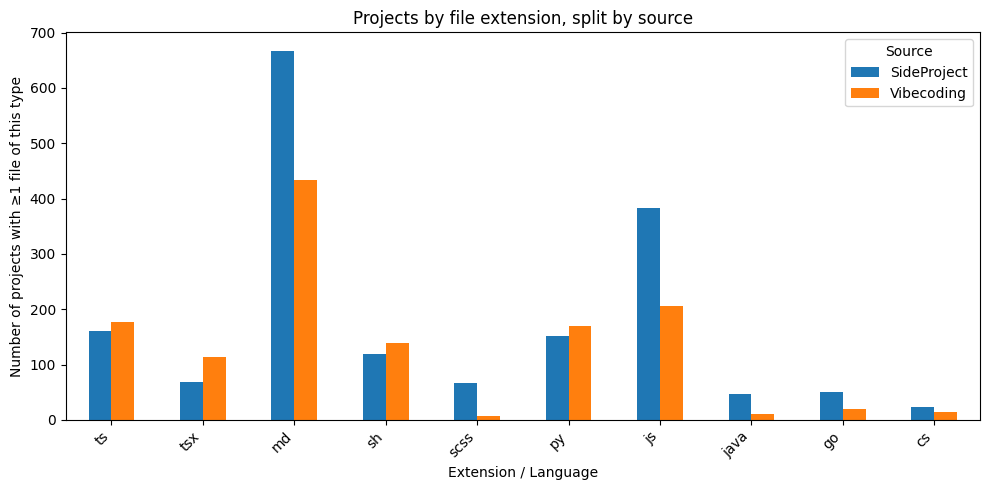

In [ ]:
project_ext_source = df_extn.drop_duplicates(subset=["proj_name", "extn", "source"])

# 3. Count unique projects per extension, split by source
counts = project_ext_source.groupby(["extn", "source"])["proj_name"].nunique().unstack(fill_value=0)

# 4. Reindex rows to preserve acceptable_exts order (fills in 0 for any missing ext)
counts = counts.reindex(acceptable_exts, fill_value=0)

# 5. Plot grouped bars
fig, ax = plt.subplots(figsize=(10, 5))
counts.plot(kind="bar", ax=ax)
ax.set_xlabel("Extension / Language")
ax.set_ylabel("Number of projects with ≥1 file of this type")
ax.set_title("Projects by file extension, split by source")
ax.legend(title="Source")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
#Do percentage

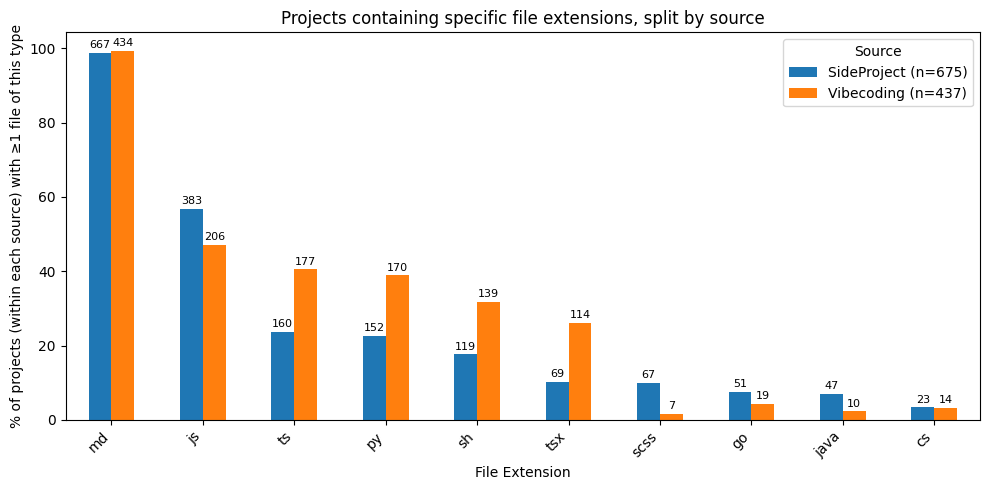

In [107]:
project_ext_source = df_all.drop_duplicates(subset=["proj_name", "extn", "source"])

# 3. Count unique projects per extension, split by source
counts = project_ext_source.groupby(["extn", "source"])["proj_name"].nunique().unstack(fill_value=0)

# 4. Reindex rows to preserve acceptable_exts order (fills in 0 for any missing ext)
counts = counts.reindex(acceptable_exts, fill_value=0)

# 4b. Total number of unique projects per source (the denominator for percentages)
total_projects_per_source = df_all.drop_duplicates(subset=["proj_name", "source"]).groupby("source")["proj_name"].nunique()

# 4c. Convert counts to percentage of that source's total projects
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]
pct = counts.div(total_projects_per_source, axis=1) * 100


# 5. Plot grouped bars (percentages), labeled with the raw counts
fig, ax = plt.subplots(figsize=(10, 5))
pct.plot(kind="bar", ax=ax)

# Add the raw project count as a label on top of each bar
for container, col in zip(ax.containers, counts.columns):
    ax.bar_label(container, labels=counts[col].values, padding=2, fontsize=8)
    #    ax.bar_label(container, labels=[f"n={v}" for v in counts[col].values], padding=2, fontsize=8)

ax.set_xlabel("File Extension")
ax.set_ylabel("% of projects (within each source) with ≥1 file of this type")
ax.set_title("Projects containing specific file extensions, split by source")
ax.legend(title="Source", labels=[f"{col} (n={total_projects_per_source[col]})" for col in pct.columns])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

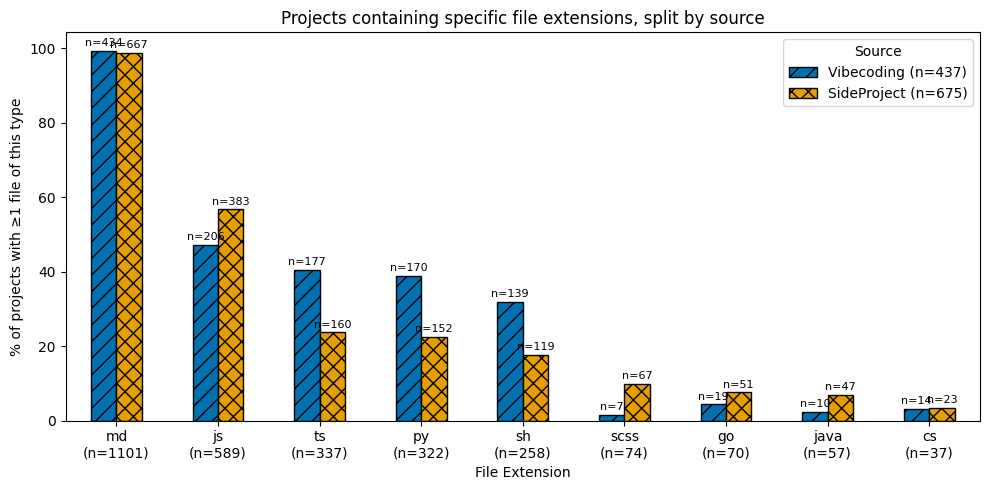

In [119]:
project_ext_source = df_all.drop_duplicates(subset=["proj_name", "extn", "source"])

# 3. Count unique projects per extension, split by source
counts = project_ext_source.groupby(["extn", "source"])["proj_name"].nunique().unstack(fill_value=0)

# 4. Reindex rows to preserve acceptable_exts order (fills in 0 for any missing ext)
counts = counts.reindex(acceptable_exts, fill_value=0)

# 4b. Total number of unique projects per source (the denominator for percentages)
total_projects_per_source = df_all.drop_duplicates(subset=["proj_name", "source"]).groupby("source")["proj_name"].nunique()

# 4c. Convert counts to percentage of that source's total projects
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]
pct = counts.div(total_projects_per_source, axis=1) * 100

# Reorder columns so "vibecoding" comes before "sideproject"
counts = counts[["Vibecoding", "SideProject"]]
pct = pct[["Vibecoding", "SideProject"]]

# Colorblind-safe palette (Okabe-Ito), plus hatching so it also reads in grayscale/print
colors = ["#0072B2", "#E69F00"]  # blue, orange
hatches = ["//", "xx"]

# 5. Plot grouped bars (percentages), labeled with the raw counts
fig, ax = plt.subplots(figsize=(10, 5))
pct.plot(kind="bar", ax=ax, color=colors, edgecolor="black")

for bars, hatch in zip(ax.containers, hatches):
    for bar in bars:
        bar.set_hatch(hatch)

# Add the raw project count as a label on top of each bar
for container, col in zip(ax.containers, counts.columns):
    ax.bar_label(container, labels=[f"n={v}" for v in counts[col].values], padding=2, fontsize=8)

ax.set_xlabel("File Extension")
ax.set_ylabel("% of projects with ≥1 file of this type")
ax.set_title("Projects containing specific file extensions, split by source")
ax.legend(title="Source", labels=[f"{col} (n={total_projects_per_source[col]})" for col in pct.columns])

# x tick labels read horizontally, with total project count (across sources) shown below each extension
ax.set_xticklabels([f"{ext}\n(n={counts.loc[ext].sum()})" for ext in counts.index], rotation=0, ha="center")

plt.tight_layout()
plt.show()

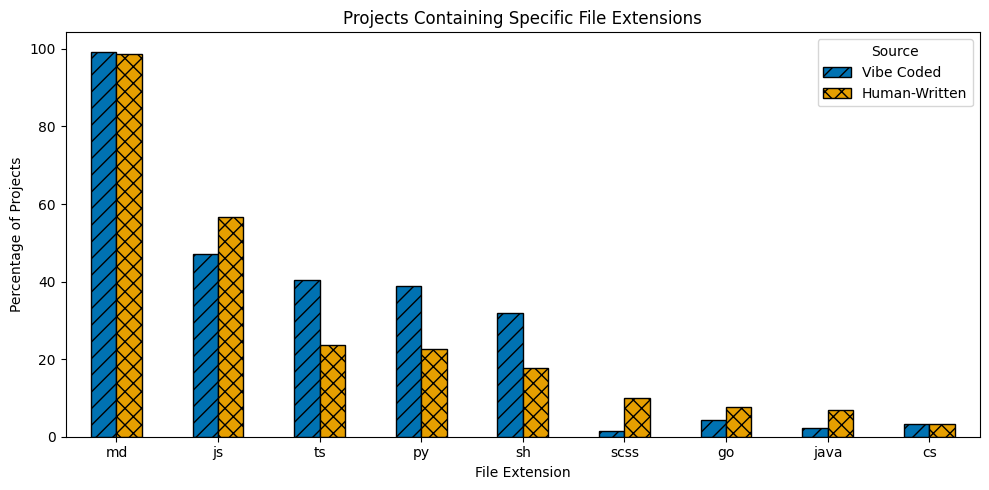

In [120]:
# One row per project / extension / source combination
project_ext_source = df_all.drop_duplicates(
    subset=["proj_name", "extn", "source"]
)

# Count unique projects per extension, split by source
counts = (
    project_ext_source
    .groupby(["extn", "source"])["proj_name"]
    .nunique()
    .unstack(fill_value=0)
)

# Preserve acceptable_exts order
counts = counts.reindex(
    acceptable_exts,
    fill_value=0
)

# Total number of unique projects per source
# Used as the denominator for percentages
total_projects_per_source = (
    df_all
    .drop_duplicates(subset=["proj_name", "source"])
    .groupby("source")["proj_name"]
    .nunique()
)

# Sort extensions by total number of projects containing them
counts = counts.loc[
    counts.sum(axis=1)
    .sort_values(ascending=False)
    .index
]

# Convert to percentage of projects in each source
pct = counts.div(
    total_projects_per_source,
    axis=1
) * 100

# Reorder columns
pct = pct[["Vibecoding", "SideProject"]]

# Publication-friendly colors and hatching
colors = ["#0072B2", "#E69F00"]
hatches = ["//", "xx"]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

pct.plot(
    kind="bar",
    ax=ax,
    color=colors,
    edgecolor="black"
)

# Add hatching
for bars, hatch in zip(ax.containers, hatches):
    for bar in bars:
        bar.set_hatch(hatch)

# Labels
ax.set_xlabel("File Extension")
ax.set_ylabel("Percentage of Projects")
ax.set_title("Projects Containing Specific File Extensions")

# Rename groups for the figure
ax.legend(
    title="Source",
    labels=["Vibe Coded", "Human-Written"]
)

# Extension names only — no counts
ax.set_xticklabels(
    pct.index,
    rotation=0,
    ha="center"
)

plt.tight_layout()
plt.show()

In [122]:
# Display names for file extensions
extension_to_language = {
    "md": "Markdown",
    "js": "JavaScript",
    "ts": "TypeScript",
    "py": "Python",
    "sh": "Shell",
    "scss": "SCSS",
    "go": "Go",
    "java": "Java",
    "cs": "C#",
}

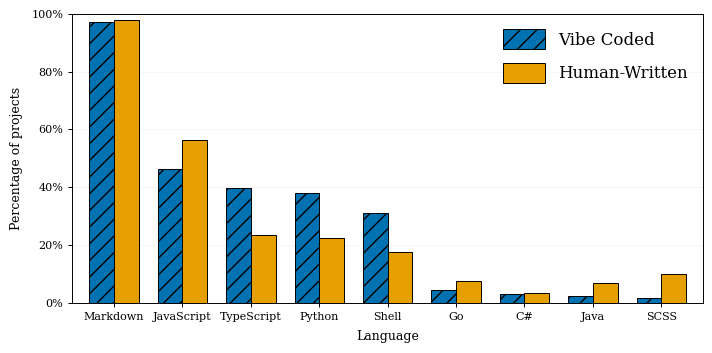

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch


# ---------------------------------------------------------
# Prepare data
# ---------------------------------------------------------

# One row per project / extension / source
project_ext_source = df_all.drop_duplicates(
    subset=["proj_name", "extn", "source"]
)

# Number of unique projects containing each extension
counts = (
    project_ext_source
    .groupby(["extn", "source"])["proj_name"]
    .nunique()
    .unstack(fill_value=0)
)

# Preserve requested extensions
counts = counts.reindex(
    acceptable_exts,
    fill_value=0
)

# Total number of projects in each source
total_projects_per_source = (
    df_all
    .drop_duplicates(subset=["proj_name", "source"])
    .groupby("source")["proj_name"]
    .nunique()
)

# Sort extensions by overall prevalence
# Sort by the number of Vibe Coded projects containing each extension
counts = counts.loc[
    counts["Vibecoding"]
    .sort_values(ascending=False)
    .index
]

# Percentage of projects in each source containing the extension
pct = counts.div(
    total_projects_per_source,
    axis=1
) * 100

# Desired ordering
pct = pct[
    ["Vibecoding", "SideProject"]
]


# ---------------------------------------------------------
# Publication formatting
# ---------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.2, 3.6)
)

# Same colorblind-safe palette style as the other figure
colors = [
    "#0072B2",   # Vibe Coded
    "#E69F00"    # Human-Written
]

# Use hatching as redundant encoding
hatches = [
    "//",        # Vibe Coded
    ""           # Human-Written
]

pct.plot(
    kind="bar",
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.7,
    width=0.72
)


# ---------------------------------------------------------
# Apply patterns
# ---------------------------------------------------------

for container, hatch in zip(
    ax.containers,
    hatches
):
    for bar in container:
        bar.set_hatch(hatch)


# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------

# ax.set_xlabel(
#     "File extension",
#     labelpad=6
# )

ax.set_xlabel("Language", labelpad=6)

ax.set_ylabel(
    "Percentage of projects",
    labelpad=6
)

# Values are already 0-100, so use 100 as PercentFormatter xmax
ax.yaxis.set_major_formatter(
    PercentFormatter(100)
)

ax.set_ylim(0, 100)

# Horizontal extension labels
ax.set_xticklabels(
    [
        extension_to_language.get(ext, ext)
        for ext in pct.index
    ],
    rotation=0,
    ha="center"
)

# Light horizontal gridlines
ax.grid(
    axis="y",
    linewidth=0.4,
    alpha=0.20,
    zorder=0
)

ax.grid(
    axis="x",
    visible=False
)

# Put bars above grid
ax.set_axisbelow(True)

# Thin frame
for spine in ax.spines.values():
    spine.set_linewidth(0.7)

ax.tick_params(
    axis="both",
    direction="out",
    length=3,
    width=0.7
)


# ---------------------------------------------------------
# Publication-facing legend
# ---------------------------------------------------------

legend_handles = [
    Patch(
        facecolor="#0072B2",
        edgecolor="black",
        hatch="//",
        linewidth=0.7,
        label="Vibe Coded"
    ),

    Patch(
        facecolor="#E69F00",
        edgecolor="black",
        linewidth=0.7,
        label="Human-Written"
    )
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False,
    fontsize=12,          # bump from the default (~8-9 in your rcParams) to make text larger
    handlelength=2.5,      # longer legend swatches (was 1.8)
    handleheight=1.5,      # taller swatches, useful for Patch handles
    labelspacing=0.8,      # more vertical space between entries
    borderaxespad=0.5
)


# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

fig.tight_layout()

plt.show()

fig.savefig(
    "lang_in_proj_distributions.pdf",
    bbox_inches="tight"
)

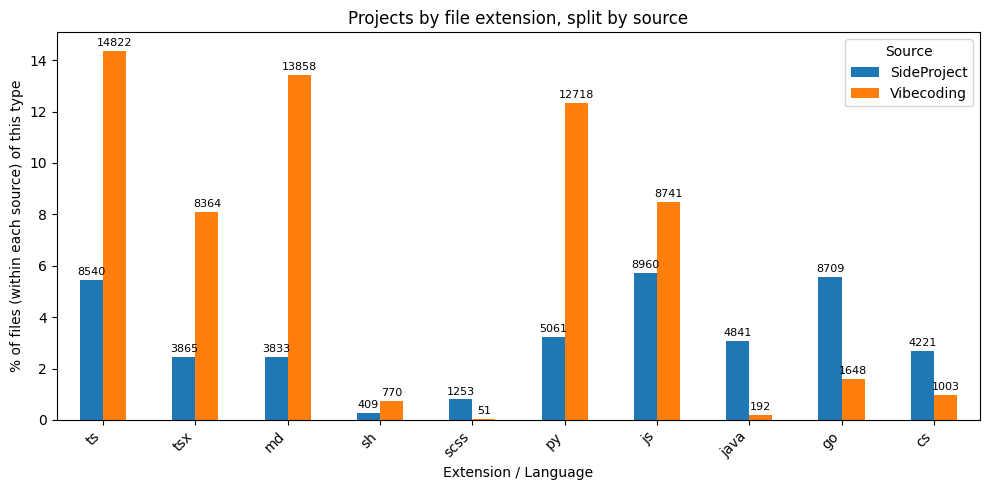

In [ ]:
project_ext_source = df_extn.drop_duplicates(subset=["file_path", "extn", "source"])

# 3. Count unique projects per extension, split by source
counts = project_ext_source.groupby(["extn", "source"])["file_path"].nunique().unstack(fill_value=0)

# 4. Reindex rows to preserve acceptable_exts order (fills in 0 for any missing ext)
counts = counts.reindex(acceptable_exts, fill_value=0)

# 5. Plot grouped bars
fig, ax = plt.subplots(figsize=(10, 5))
counts.plot(kind="bar", ax=ax)
ax.set_xlabel("Extension / Language")
ax.set_ylabel("Number files of this type")
ax.set_title("Files by file extension, split by source")
ax.legend(title="Source")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

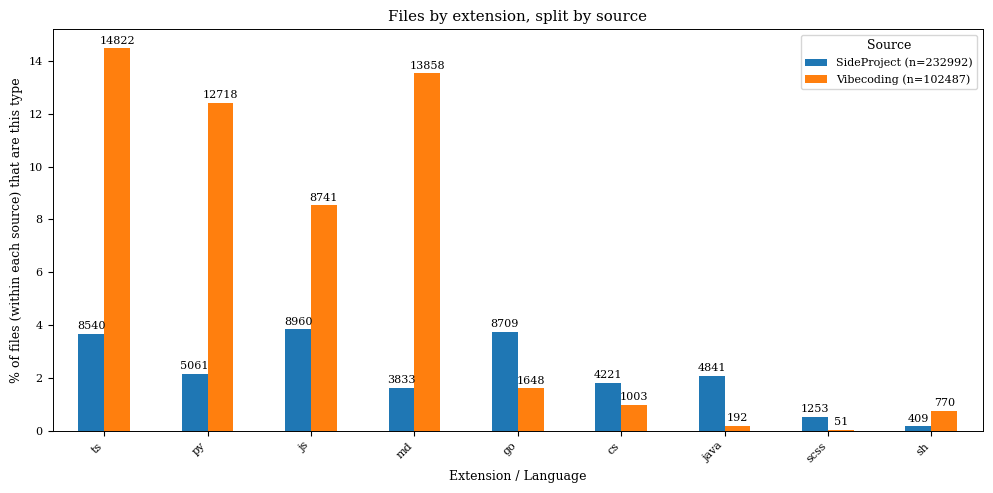

In [132]:
# 3. Count number of files per extension, split by source
counts = df_all.groupby(["extn", "source"]).size().unstack(fill_value=0)

# 4. Reindex rows to preserve acceptable_exts order (fills in 0 for any missing ext)
counts = counts.reindex(acceptable_exts, fill_value=0)

# 4b. Total number of files per source (the denominator for percentages)
total_files_per_source = df_all.groupby("source").size()

# 4c. Convert counts to percentage of that source's total files
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]
pct = counts.div(total_files_per_source, axis=1) * 100

# 5. Plot grouped bars (percentages), labeled with the raw counts
fig, ax = plt.subplots(figsize=(10, 5))
pct.plot(kind="bar", ax=ax)

# Add the raw file count as a label on top of each bar
for container, col in zip(ax.containers, counts.columns):
    ax.bar_label(container, labels=counts[col].values, padding=2, fontsize=8)

ax.set_xlabel("Extension / Language")
ax.set_ylabel("% of files (within each source) that are this type")
ax.set_title("Files by extension, split by source")
ax.legend(title="Source", labels=[f"{col} (n={total_files_per_source[col]})" for col in pct.columns])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

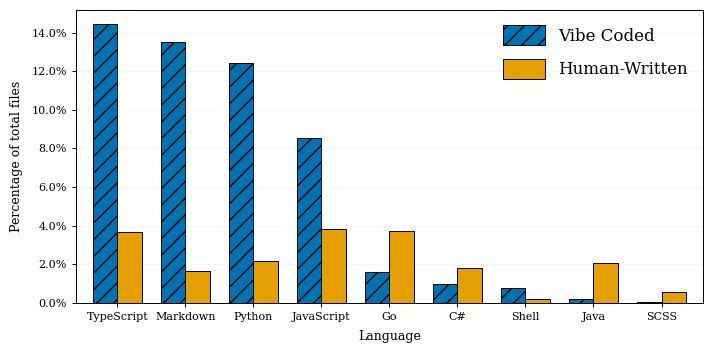

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch


# ---------------------------------------------------------
# Display names for extensions
# ---------------------------------------------------------

extension_to_language = {
    "md": "Markdown",
    "js": "JavaScript",
    "ts": "TypeScript",
    "py": "Python",
    "sh": "Shell",
    "scss": "SCSS",
    "go": "Go",
    "java": "Java",
    "cs": "C#",
}


# ---------------------------------------------------------
# Prepare data
# ---------------------------------------------------------

# Count number of files per extension and source
counts = (
    df_all
    .groupby(["extn", "source"])
    .size()
    .unstack(fill_value=0)
)

# Keep only requested extensions
counts = counts.reindex(
    acceptable_exts,
    fill_value=0
)

# Total number of files in each source.
# These are the denominators for the percentages.
total_files_per_source = (
    df_all
    .groupby("source")
    .size()
)


# ---------------------------------------------------------
# Sort by prevalence among Vibe Coded files
# ---------------------------------------------------------

counts = counts.loc[
    counts["Vibecoding"]
    .sort_values(ascending=False)
    .index
]


# ---------------------------------------------------------
# Convert counts to percentage within each source
# ---------------------------------------------------------

pct = counts.div(
    total_files_per_source,
    axis=1
) * 100

# Keep consistent group ordering
pct = pct[
    ["Vibecoding", "SideProject"]
]


# ---------------------------------------------------------
# Publication formatting
# ---------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.2, 3.6)
)

# Same colors as previous figure
colors = [
    "#0072B2",   # Vibe Coded
    "#E69F00"    # Human-Written
]

pct.plot(
    kind="bar",
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.7,
    width=0.72
)


# ---------------------------------------------------------
# Apply hatching
# ---------------------------------------------------------

# Vibe Coded = hatched
# Human-Written = solid
hatches = [
    "//",
    ""
]

for container, hatch in zip(
    ax.containers,
    hatches
):
    for bar in container:
        bar.set_hatch(hatch)


# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------

ax.set_xlabel(
    "Language",
    labelpad=6
)

ax.set_ylabel(
    "Percentage of total files",
    labelpad=6
)

# Data are already expressed from 0 to 100
ax.yaxis.set_major_formatter(
    PercentFormatter(100)
)

# Start at zero, but let matplotlib choose an appropriate
# upper limit based on the actual data.
ax.set_ylim(
    bottom=0
)

# Replace extensions with language/file-type names
ax.set_xticklabels(
    [
        extension_to_language.get(ext, ext)
        for ext in pct.index
    ],
    rotation=0,
    ha="center"
)


# ---------------------------------------------------------
# Grid and frame
# ---------------------------------------------------------

ax.grid(
    axis="y",
    linewidth=0.4,
    alpha=0.20,
    zorder=0
)

ax.grid(
    axis="x",
    visible=False
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(0.7)

ax.tick_params(
    axis="both",
    direction="out",
    length=3,
    width=0.7
)


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

legend_handles = [
    Patch(
        facecolor="#0072B2",
        edgecolor="black",
        hatch="//",
        linewidth=0.7,
        label="Vibe Coded"
    ),

    Patch(
        facecolor="#E69F00",
        edgecolor="black",
        linewidth=0.7,
        label="Human-Written"
    )
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False,
    fontsize=12,          # bump from the default (~8-9 in your rcParams) to make text larger
    handlelength=2.5,      # longer legend swatches (was 1.8)
    handleheight=1.5,      # taller swatches, useful for Patch handles
    labelspacing=0.8,      # more vertical space between entries
    borderaxespad=0.5
)


# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

fig.tight_layout()

plt.show()

fig.savefig(
    "file_type_distribution.pdf",
    format="pdf",
    bbox_inches="tight"
)

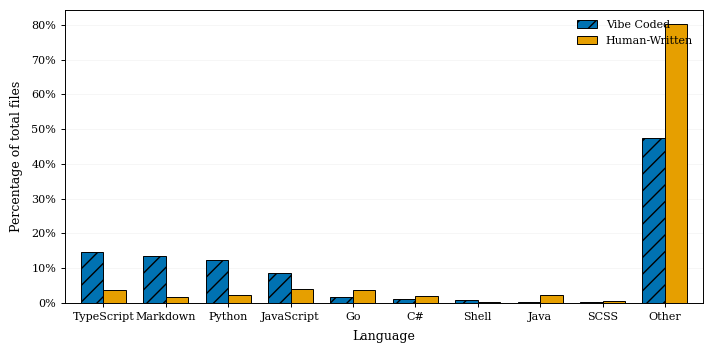

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch


# ---------------------------------------------------------
# Display names for extensions
# ---------------------------------------------------------

extension_to_language = {
    "md": "Markdown",
    "js": "JavaScript",
    "ts": "TypeScript",
    "py": "Python",
    "sh": "Shell",
    "scss": "SCSS",
    "go": "Go",
    "java": "Java",
    "cs": "C#",
}


# ---------------------------------------------------------
# Prepare data
# ---------------------------------------------------------

# Count number of files per extension and source
all_counts = (
    df_all
    .groupby(["extn", "source"])
    .size()
    .unstack(fill_value=0)
)


# ---------------------------------------------------------
# Get counts for the nine selected extensions
# ---------------------------------------------------------

counts = all_counts.reindex(
    acceptable_exts,
    fill_value=0
)


# ---------------------------------------------------------
# Add "Other"
# ---------------------------------------------------------

# Count ALL files whose extension is not one of the
# nine selected extensions
other_counts = (
    df_all[
        ~df_all["extn"].isin(acceptable_exts)
    ]
    .groupby("source")
    .size()
)

# Add those counts as an "Other" row
counts.loc["Other"] = (
    other_counts.reindex(
        counts.columns,
        fill_value=0
    )
)


# ---------------------------------------------------------
# Total number of files in each source
# ---------------------------------------------------------

# Denominator includes ALL files, including "Other"
total_files_per_source = (
    df_all
    .groupby("source")
    .size()
)


# ---------------------------------------------------------
# Sort by prevalence among Vibe Coded files
# while keeping Other at the end
# ---------------------------------------------------------

selected_order = (
    counts
    .drop(index="Other")
    ["Vibecoding"]
    .sort_values(ascending=False)
    .index
)

counts = counts.loc[
    list(selected_order) + ["Other"]
]


# ---------------------------------------------------------
# Convert counts to percentage within each source
# ---------------------------------------------------------

pct = counts.div(
    total_files_per_source,
    axis=1
) * 100

# Keep consistent group ordering
pct = pct[
    ["Vibecoding", "SideProject"]
]

# ---------------------------------------------------------
# Publication formatting
# ---------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.2, 3.6)
)

# Same colors as previous figure
colors = [
    "#0072B2",   # Vibe Coded
    "#E69F00"    # Human-Written
]

pct.plot(
    kind="bar",
    ax=ax,
    color=colors,
    edgecolor="black",
    linewidth=0.7,
    width=0.72
)


# ---------------------------------------------------------
# Apply hatching
# ---------------------------------------------------------

# Vibe Coded = hatched
# Human-Written = solid
hatches = [
    "//",
    ""
]

for container, hatch in zip(
    ax.containers,
    hatches
):
    for bar in container:
        bar.set_hatch(hatch)


# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------

ax.set_xlabel(
    "Language",
    labelpad=6
)

ax.set_ylabel(
    "Percentage of total files",
    labelpad=6
)

# Data are already expressed from 0 to 100
ax.yaxis.set_major_formatter(
    PercentFormatter(100)
)

# Start at zero, but let matplotlib choose an appropriate
# upper limit based on the actual data.
ax.set_ylim(
    bottom=0
)

# Replace extensions with language/file-type names
ax.set_xticklabels(
    [
        extension_to_language.get(ext, ext)
        for ext in pct.index
    ],
    rotation=0,
    ha="center"
)


# ---------------------------------------------------------
# Grid and frame
# ---------------------------------------------------------

ax.grid(
    axis="y",
    linewidth=0.4,
    alpha=0.20,
    zorder=0
)

ax.grid(
    axis="x",
    visible=False
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(0.7)

ax.tick_params(
    axis="both",
    direction="out",
    length=3,
    width=0.7
)


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

legend_handles = [
    Patch(
        facecolor="#0072B2",
        edgecolor="black",
        hatch="//",
        linewidth=0.7,
        label="Vibe Coded"
    ),

    Patch(
        facecolor="#E69F00",
        edgecolor="black",
        linewidth=0.7,
        label="Human-Written"
    )
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False,
    handlelength=1.8,
    borderaxespad=0.5
)


# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

fig.tight_layout()

plt.show()

fig.savefig(
    "file_type_distribution.pdf",
    format="pdf",
    bbox_inches="tight"
)

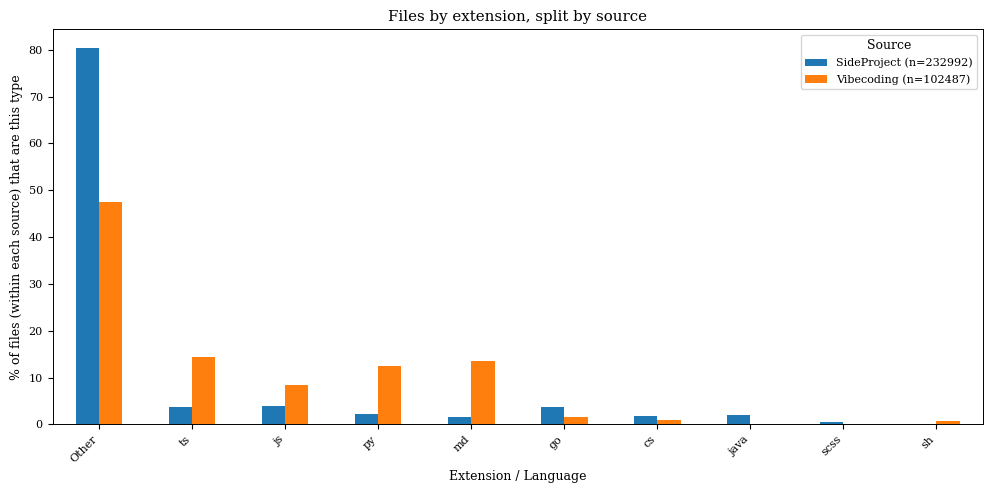

In [154]:
# 3. Count number of files per extension, split by source
counts = df_extn.groupby(["extn", "source"]).size().unstack(fill_value=0)

# 4. Reindex rows to preserve acceptable_exts order (fills in 0 for any missing ext)
counts = counts.reindex(acceptable_exts, fill_value=0)

# 4a. Build an "Other" row from everything NOT in acceptable_exts
other_counts = df_all[~df_all["extn"].isin(acceptable_exts)].groupby("source").size()
counts.loc["Other"] = other_counts.reindex(counts.columns, fill_value=0)

# 4b. Total number of files per source (denominator now includes Other, i.e. ALL files)
total_files_per_source = df_all.groupby("source").size()

# 4c. Convert counts to percentage of that source's total files
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]
pct = counts.div(total_files_per_source, axis=1) * 100

# 5. Plot grouped bars (percentages), labeled with the raw counts
fig, ax = plt.subplots(figsize=(10, 5))
pct.plot(kind="bar", ax=ax)

# Add the raw file count as a label on top of each bar
# for container, col in zip(ax.containers, counts.columns):
#     ax.bar_label(container, labels=[f"n={v}" for v in counts[col].values], padding=2, fontsize=8)

ax.set_xlabel("Extension / Language")
ax.set_ylabel("% of files (within each source) that are this type")
ax.set_title("Files by extension, split by source")
ax.legend(title="Source", labels=[f"{col} (n={total_files_per_source[col]})" for col in pct.columns])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [155]:
pct

source,SideProject,Vibecoding
extn,,
Other,80.331084,47.502610
ts,3.665362,14.462322
js,3.987691,8.528887
py,2.172178,12.409379
md,1.652417,13.521715
go,3.737897,1.608009
cs,1.811650,0.978661
java,2.077754,0.187341
scss,0.537787,0.049762


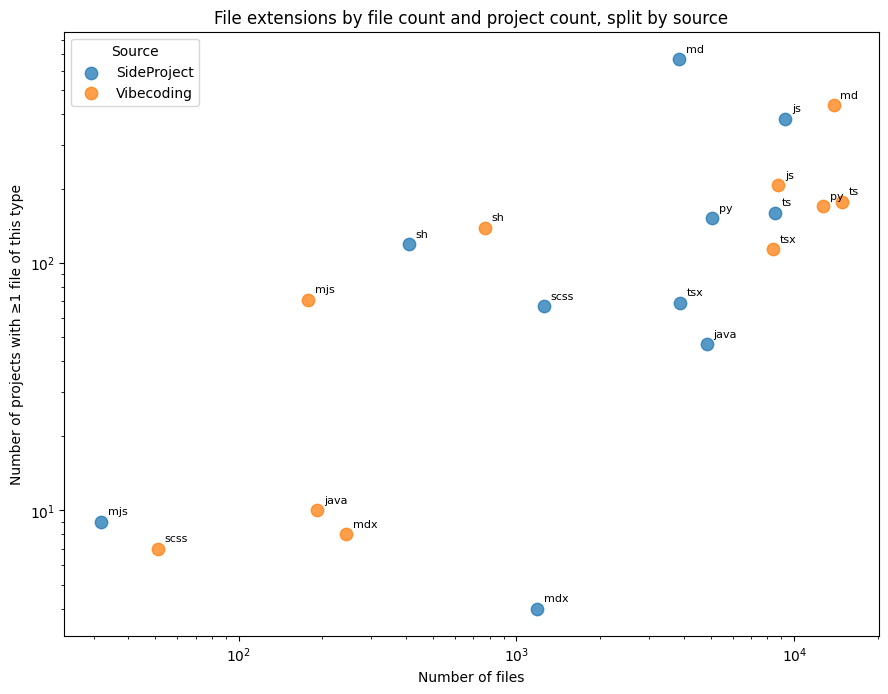

In [22]:
import pandas as pd
import matplotlib.pyplot as plt



# 2. Aggregate per (extn, source): number of files, and number of unique projects
agg = df_extn.groupby(["extn", "source"]).agg(
    n_files=("file_name", "count"),
    n_projects=("proj_name", "nunique")
).reset_index()

# 3. Scatterplot: x = n_files, y = n_projects, color = source, label = extn
fig, ax = plt.subplots(figsize=(9, 7))

for src, group in agg.groupby("source"):
    ax.scatter(group["n_files"], group["n_projects"], label=src, s=80, alpha=0.75)

# Annotate each point with its extension
for _, row in agg.iterrows():
    ax.annotate(row["extn"], (row["n_files"], row["n_projects"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("Number of files")
ax.set_ylabel("Number of projects with ≥1 file of this type")
ax.set_title("File extensions by file count and project count, split by source")
ax.legend(title="Source")
plt.tight_layout()
ax.set_xscale("log")
ax.set_yscale("log")
plt.show()

# Files per project

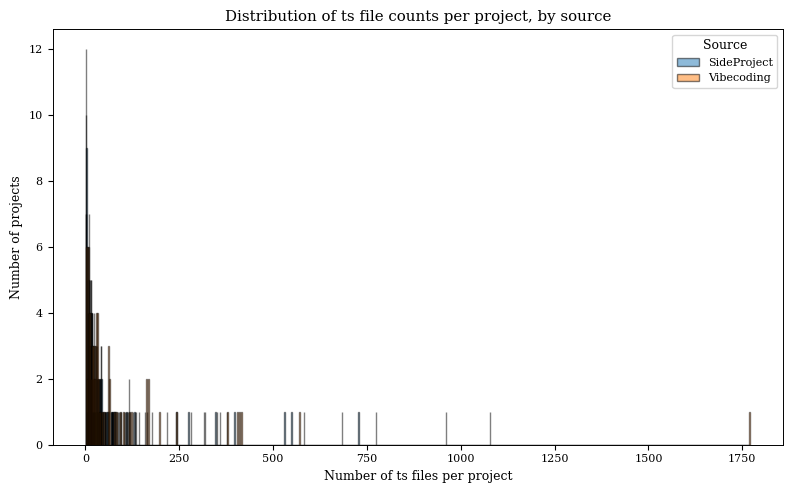

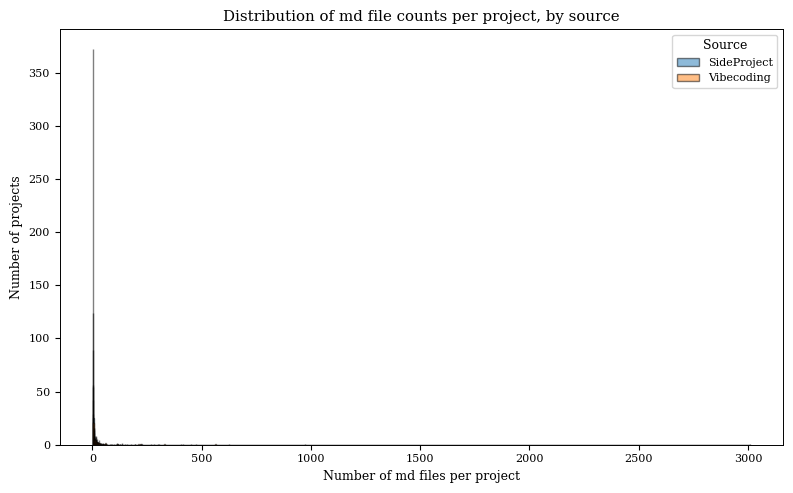

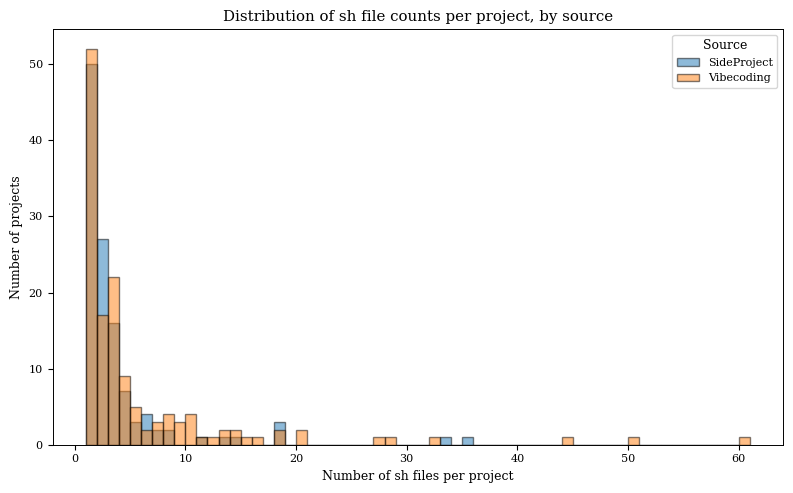

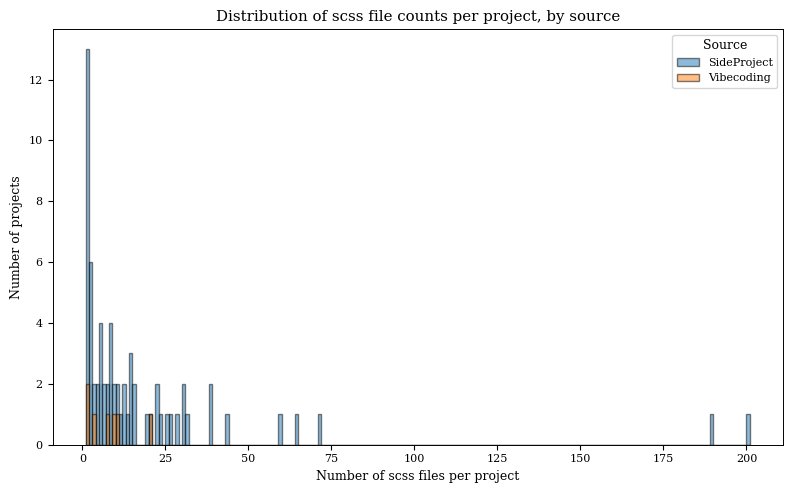

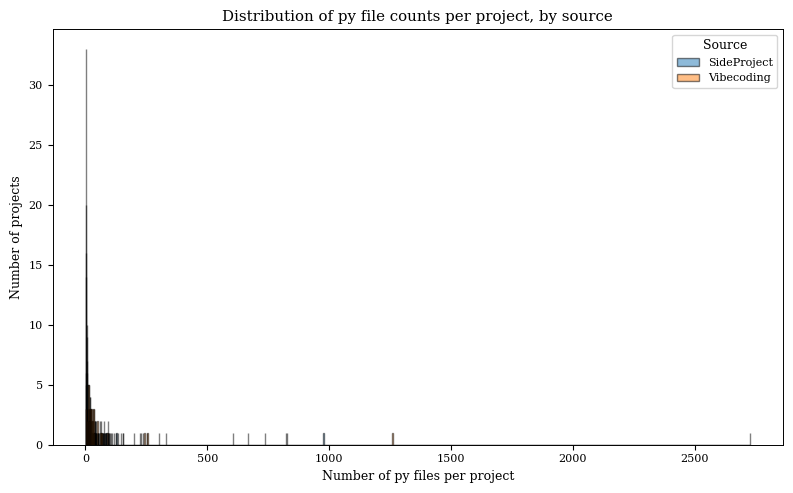

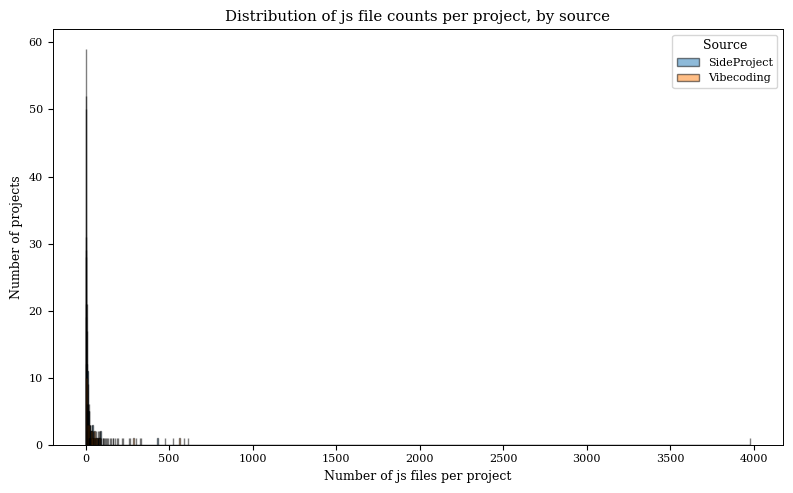

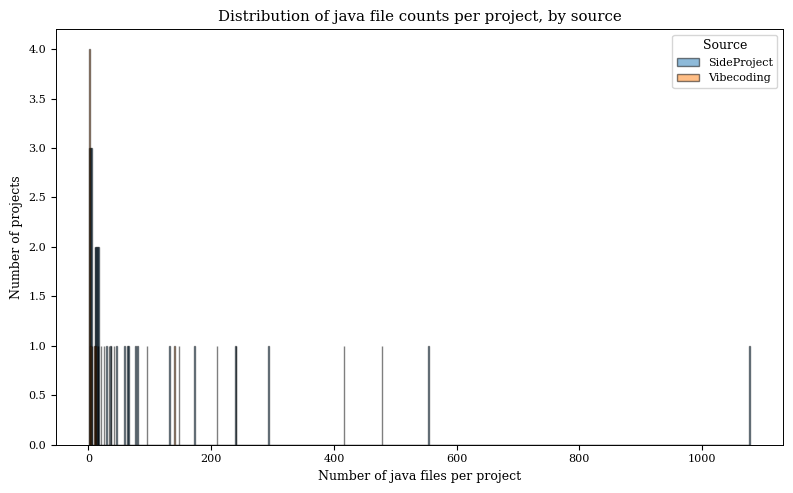

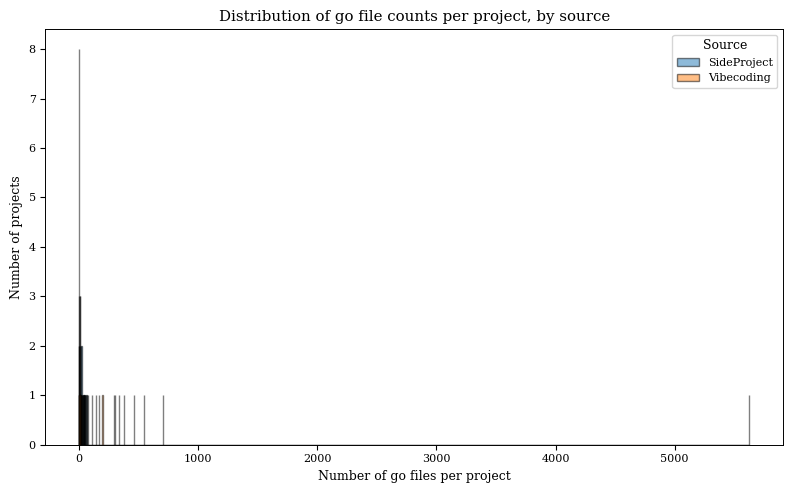

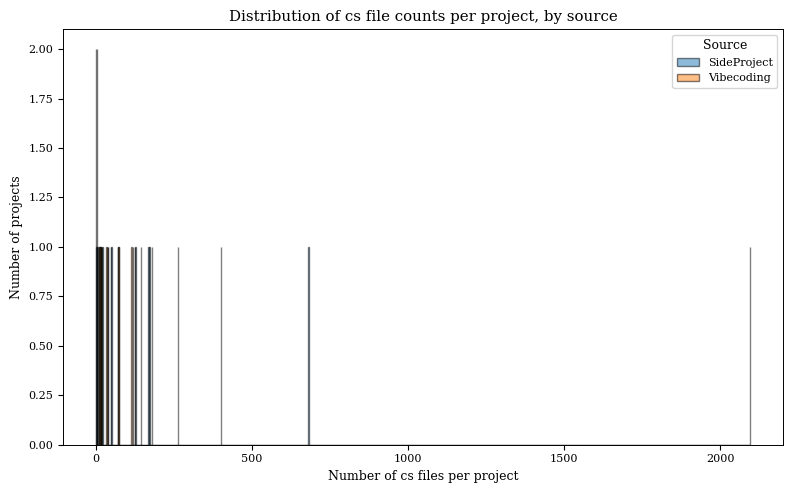

In [150]:


for ext in acceptable_exts:
    # 1. Only files of this extension
    df_ext = df_all[df_all["extn"] == ext]

    if df_ext.empty:
        continue  # skip extensions with no matching files at all

    # 2. Count files of this extension per project, per source
    #    (only projects that have >=1 file of this extension appear here)
    counts = df_ext.groupby(["source", "proj_name"]).size().reset_index(name="n_files")

    # 3. Shared bins so both source histograms are comparable
    max_count = counts["n_files"].max()
    bins = range(1, max_count + 2)  # integer bins: 1,2,3,...,max+1

    fig, ax = plt.subplots(figsize=(8, 5))

    for src, group in counts.groupby("source"):
        ax.hist(group["n_files"], bins=bins, alpha=0.5, label=src, edgecolor="black")

    ax.set_xlabel(f"Number of {ext} files per project")
    ax.set_ylabel("Number of projects")
    ax.set_title(f"Distribution of {ext} file counts per project, by source")
    ax.legend(title="Source")
    plt.tight_layout()
    plt.show()

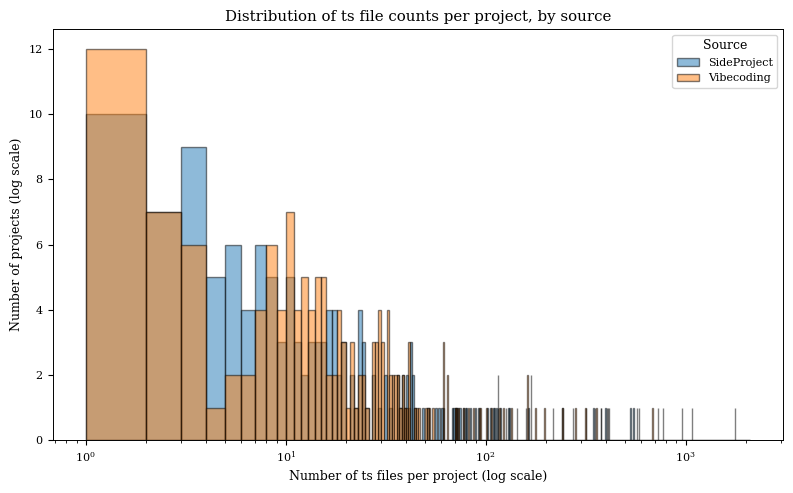

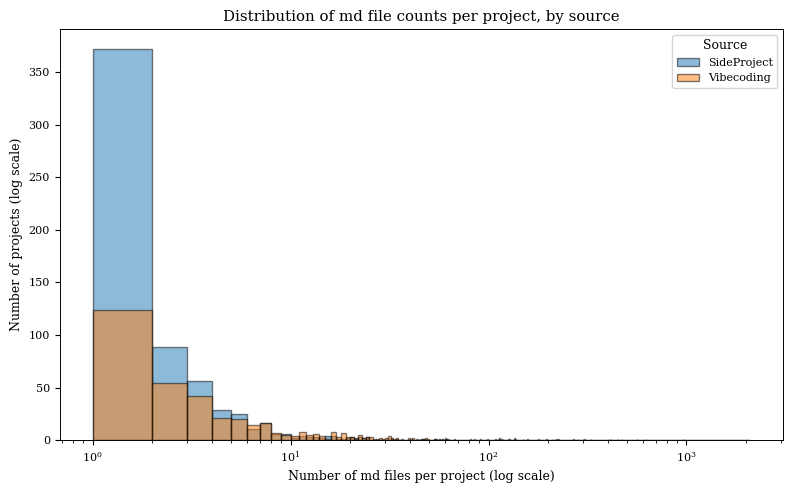

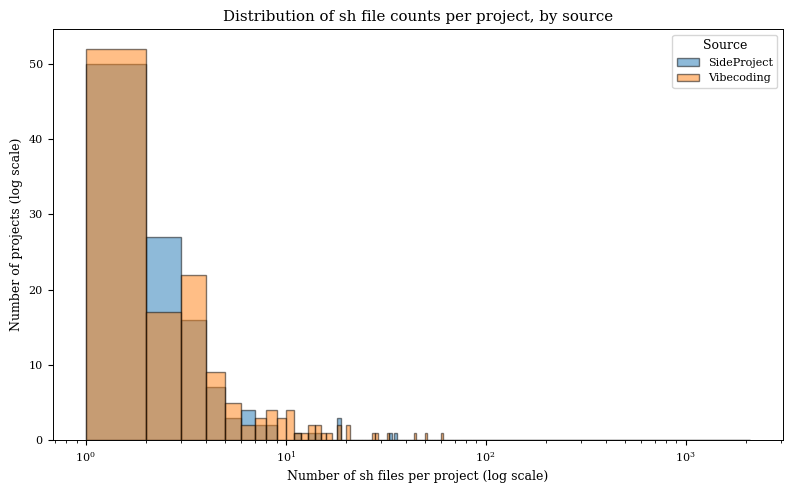

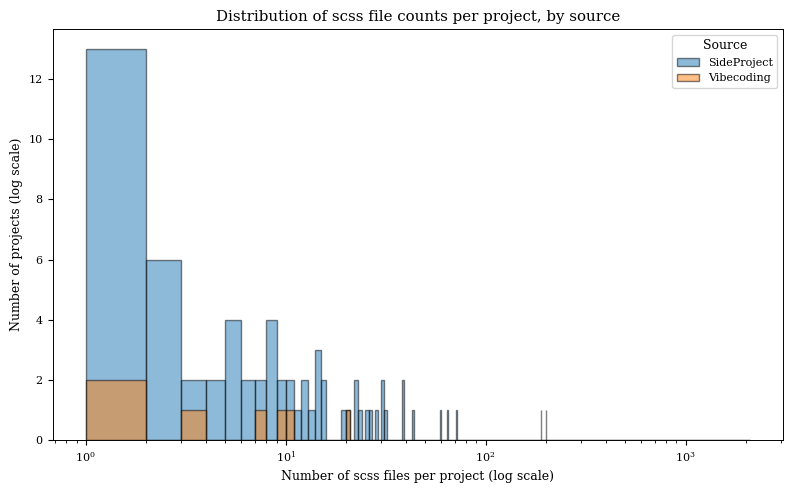

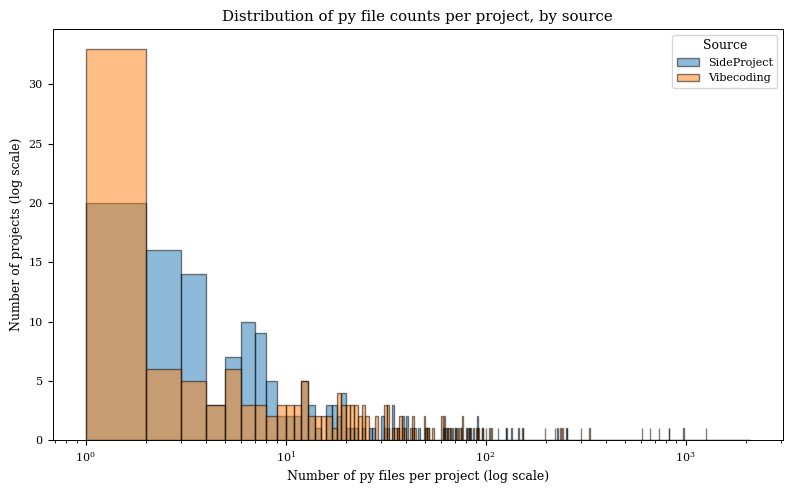

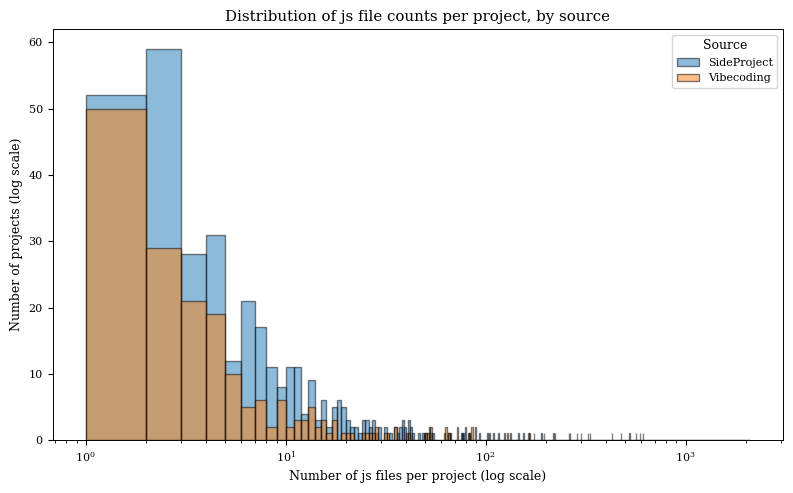

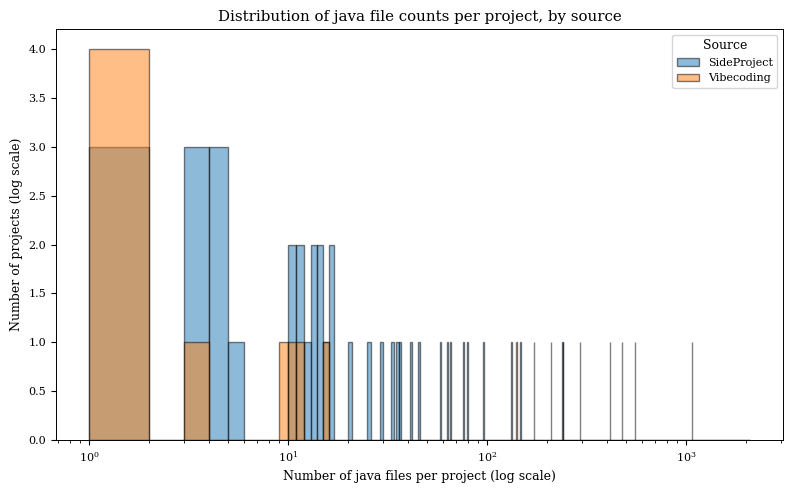

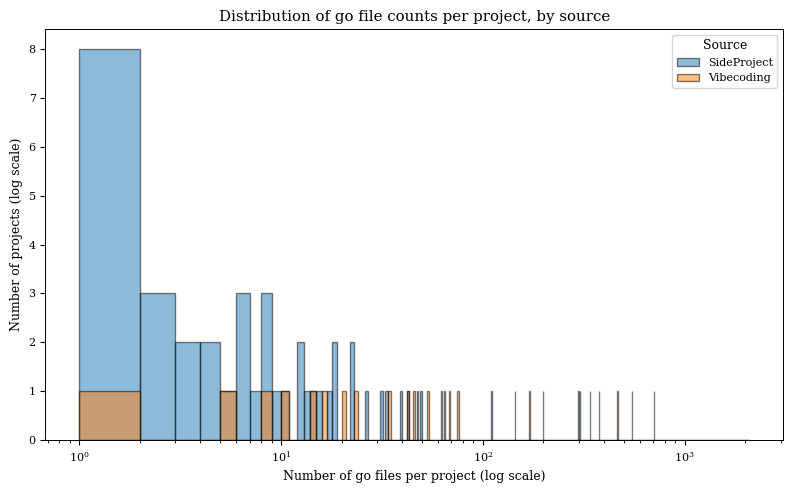

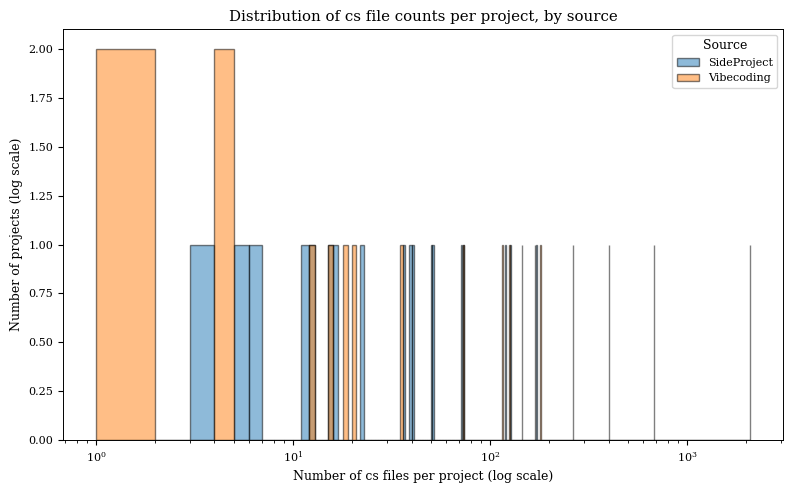

In [ ]:

for ext in acceptable_exts:
    df_ext = df_all[df_all["extn"] == ext]

    if df_ext.empty:
        continue

    counts = df_ext.groupby(["source", "proj_name"]).size().reset_index(name="n_files")

    max_count = counts["n_files"].max()
    min_count = counts["n_files"].min()

    # Log-spaced bins from min to max count (20 bins across the range)
    # bins = np.logspace(np.log10(max(min_count, 1)), np.log10(max_count), 20)
    # bins=60

    fig, ax = plt.subplots(figsize=(8, 5))

    for src, group in counts.groupby("source"):
        ax.hist(group["n_files"], bins=bins, alpha=0.5, label=src, edgecolor="black")

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(f"Number of {ext} files per project (log scale)")
    ax.set_ylabel("Number of projects (log scale)")
    ax.set_title(f"Distribution of {ext} file counts per project, by source")
    ax.legend(title="Source")
    plt.tight_layout()
    plt.show()

# File Length by extension and source

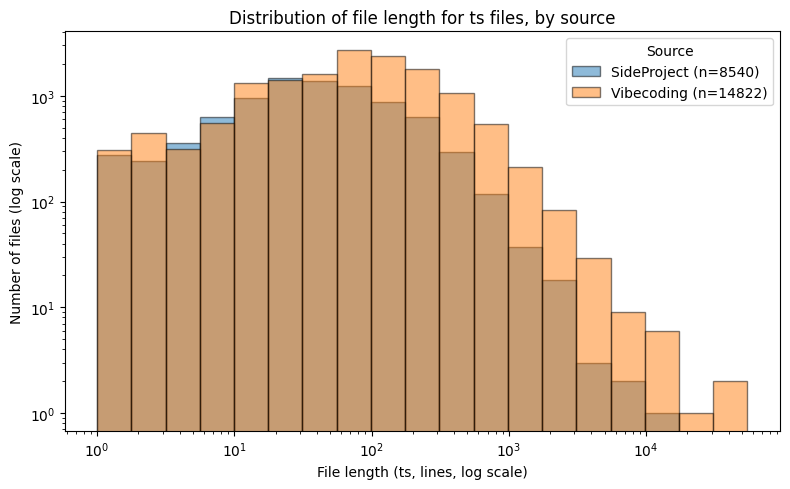

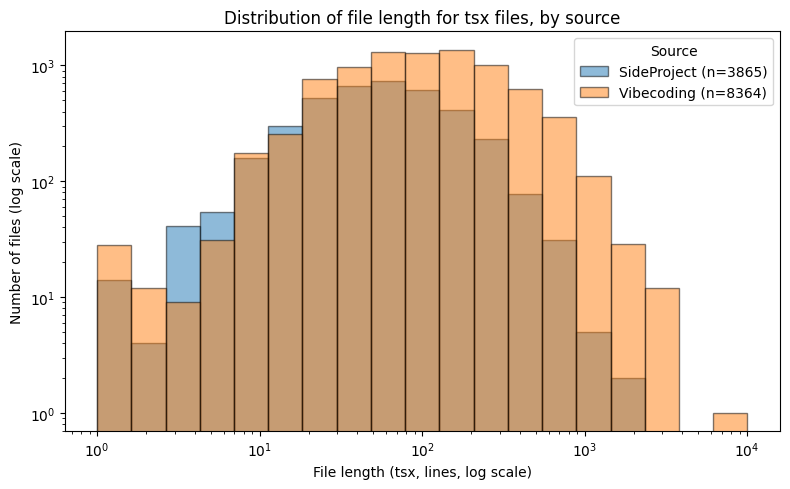

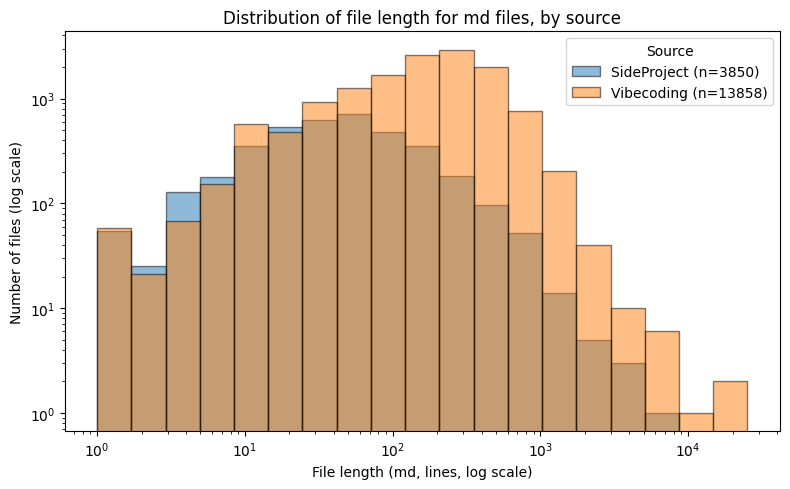

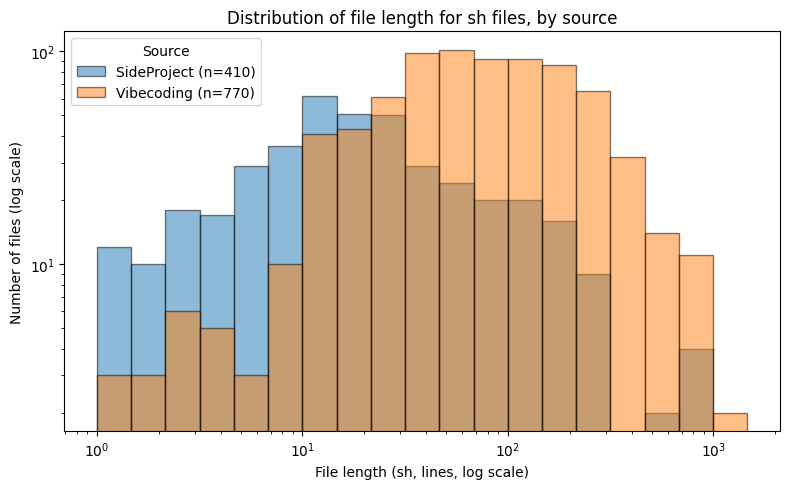

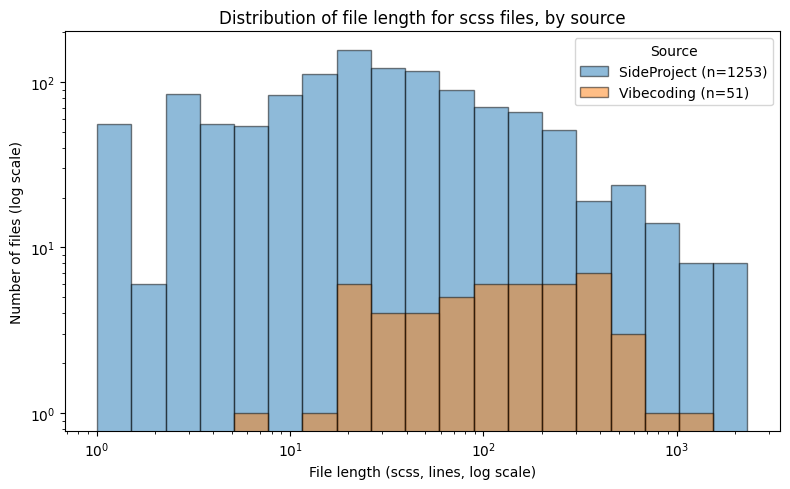

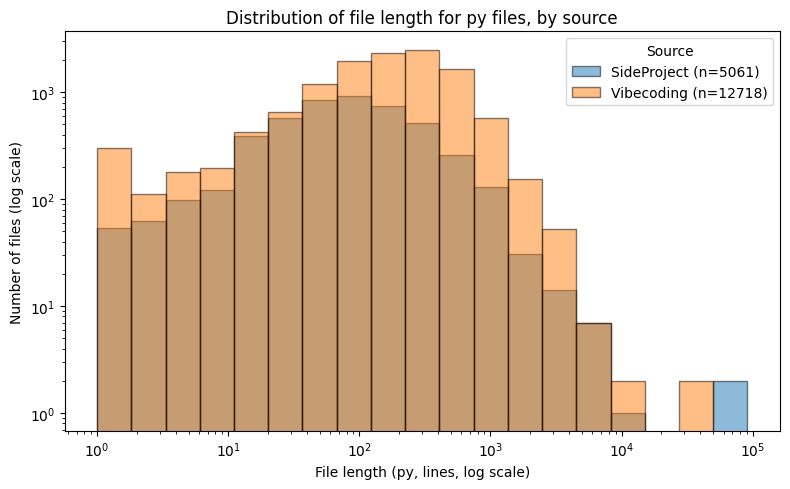

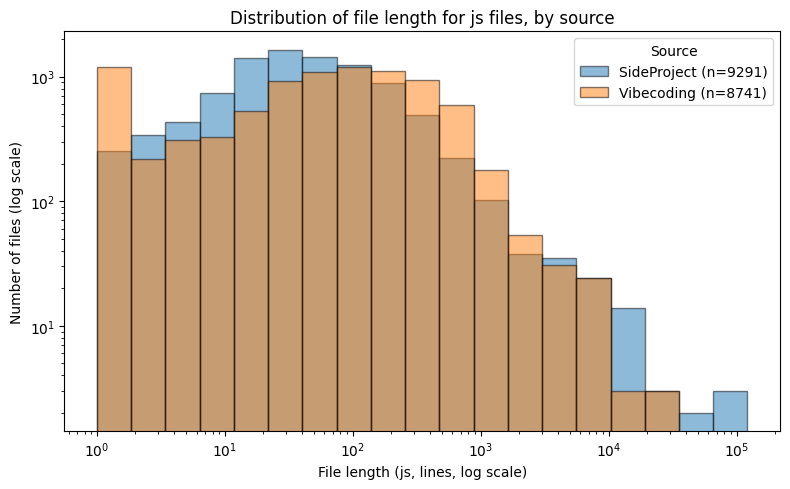

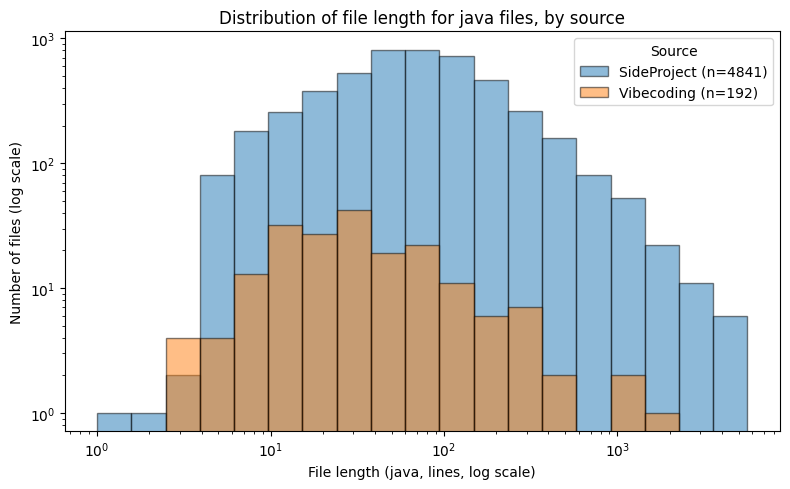

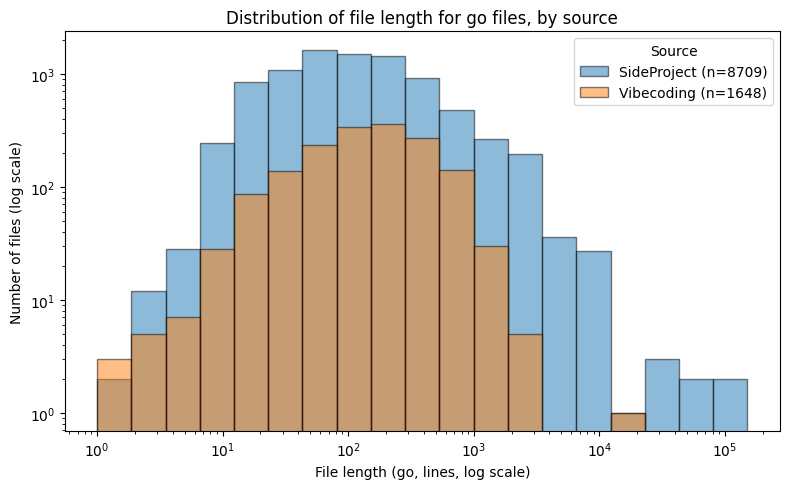

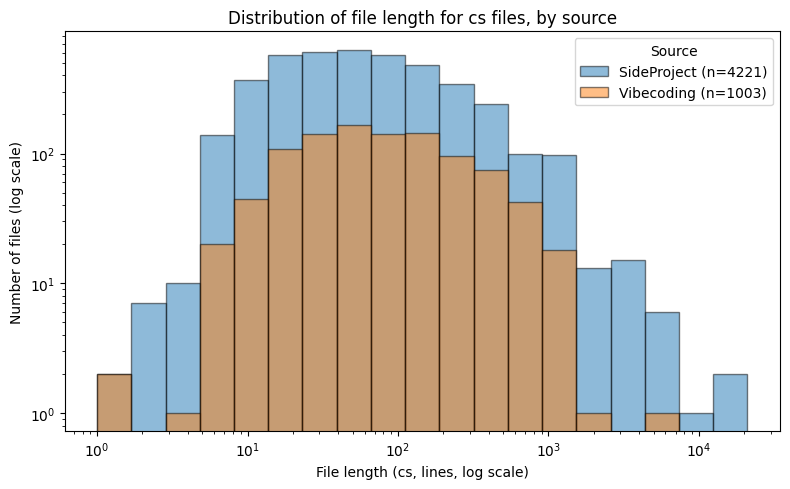

In [66]:


for ext in acceptable_exts:
    df_ext = df_all[df_all["extn"] == ext]

    if df_ext.empty:
        continue

    max_len = df_ext["n_lines"].max()
    min_len = df_ext["n_lines"].min()

    bins = np.logspace(np.log10(max(min_len, 1)), np.log10(max(max_len, 1)), 20)

    fig, ax = plt.subplots(figsize=(8, 5))

    for src, group in df_ext.groupby("source"):
        n = len(group)
        ax.hist(group["n_lines"], bins=bins, alpha=0.5,
                 label=f"{src} (n={n})", edgecolor="black")

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(f"File length ({ext}, lines, log scale)")
    ax.set_ylabel("Number of files (log scale)")
    ax.set_title(f"Distribution of file length for {ext} files, by source")
    ax.legend(title="Source")
    plt.tight_layout()
    plt.show()

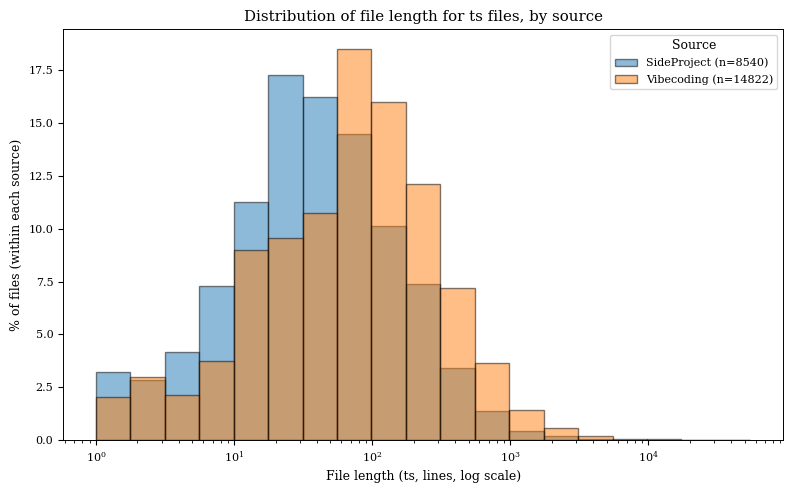

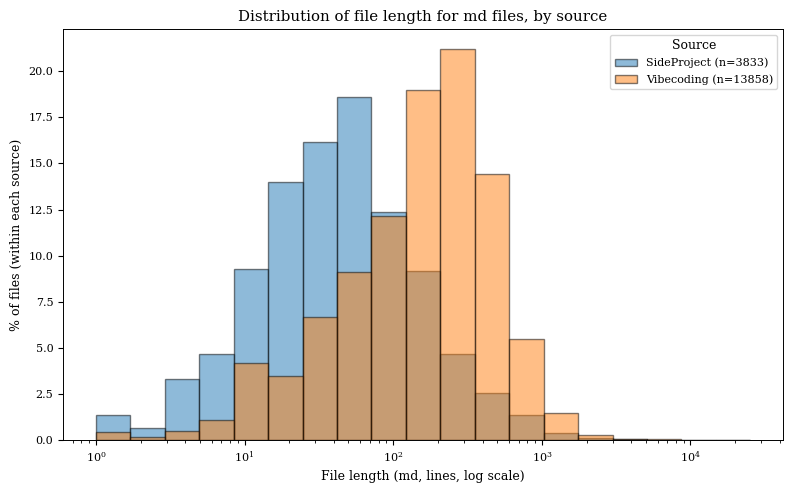

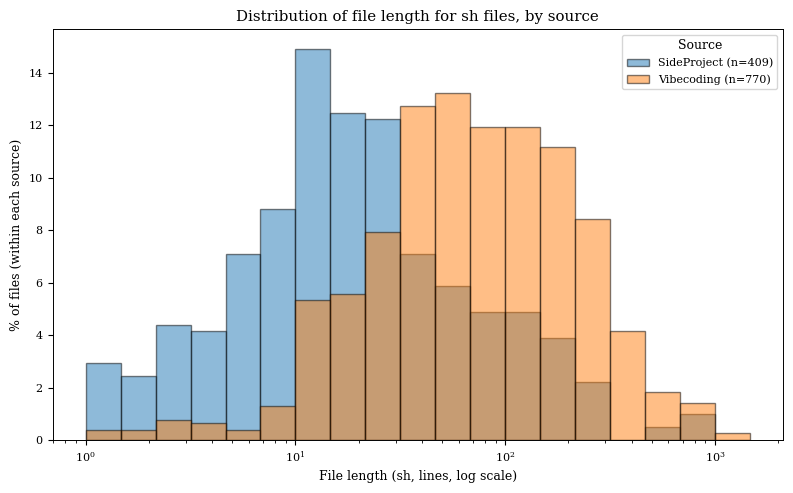

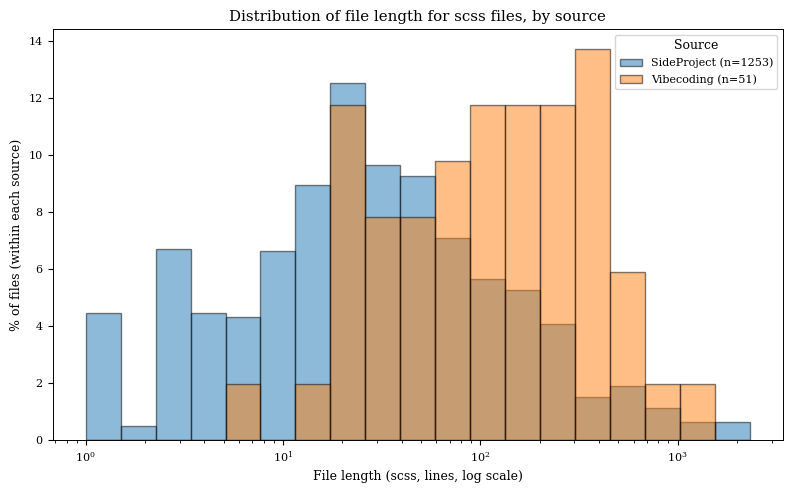

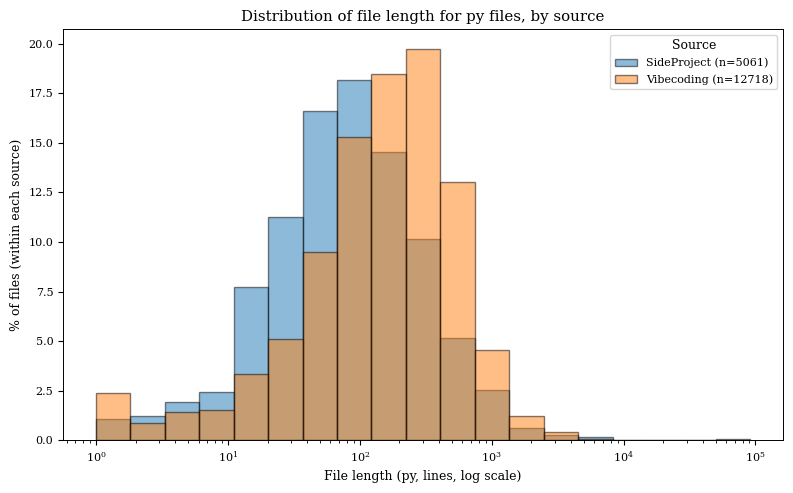

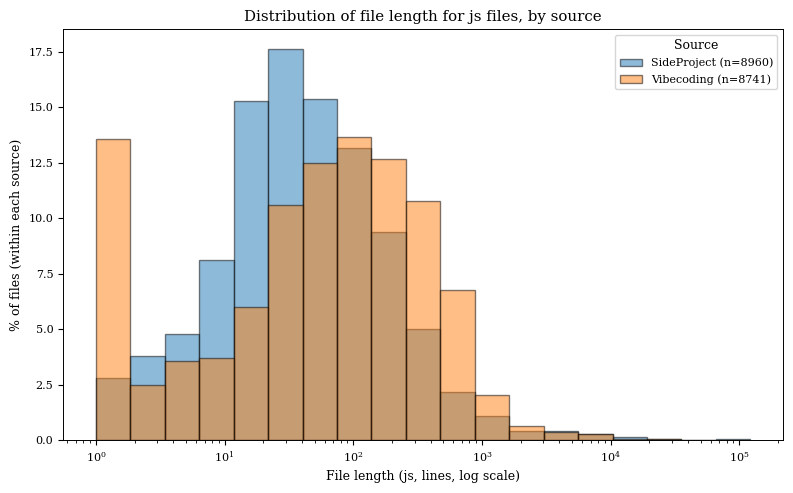

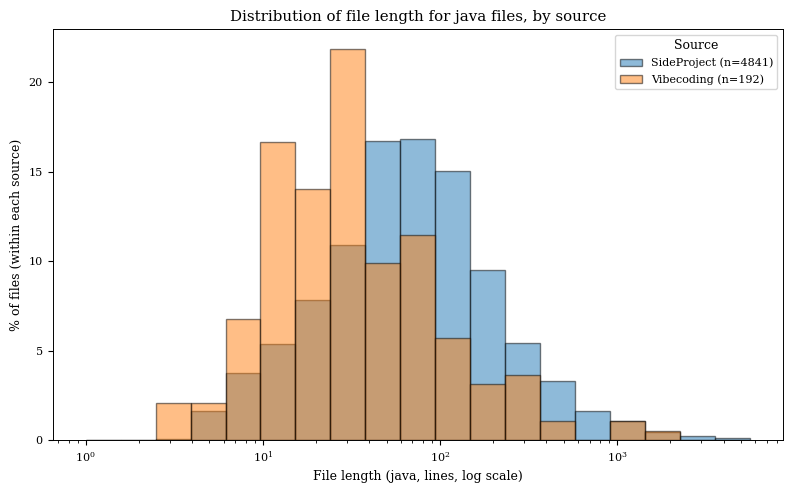

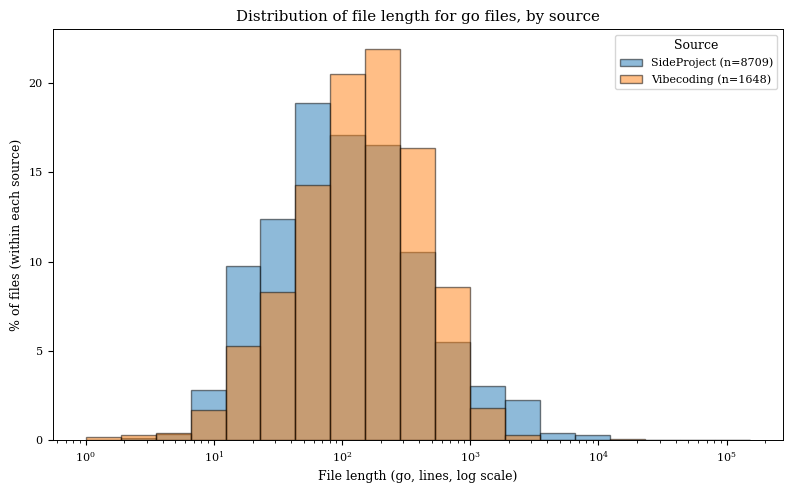

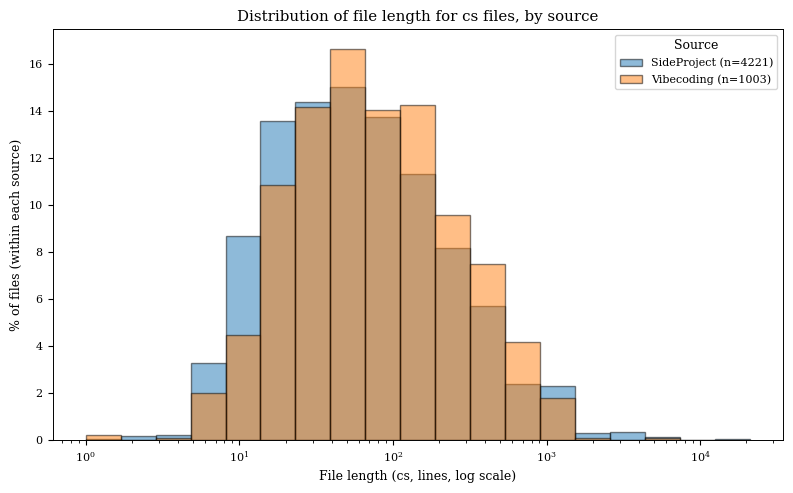

In [149]:
for ext in acceptable_exts:
    df_ext = df_all[df_all["extn"] == ext]

    if df_ext.empty:
        continue

    max_len = df_ext["n_lines"].max()
    min_len = df_ext["n_lines"].min()

    bins = np.logspace(np.log10(max(min_len, 1)), np.log10(max(max_len, 1)), 20)

    fig, ax = plt.subplots(figsize=(8, 5))

    for src, group in df_ext.groupby("source"):
        n = len(group)
        weights = np.full(n, 100 / n)  # each bar sums to 100% within this source
        ax.hist(group["n_lines"], bins=bins, weights=weights, alpha=0.5,
                 label=f"{src} (n={n})", edgecolor="black")

    ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.set_xlabel(f"File length ({ext}, lines, log scale)")
    ax.set_ylabel("% of files (within each source)")
    ax.set_title(f"Distribution of file length for {ext} files, by source")
    ax.legend(title="Source")
    plt.tight_layout()
    plt.show()

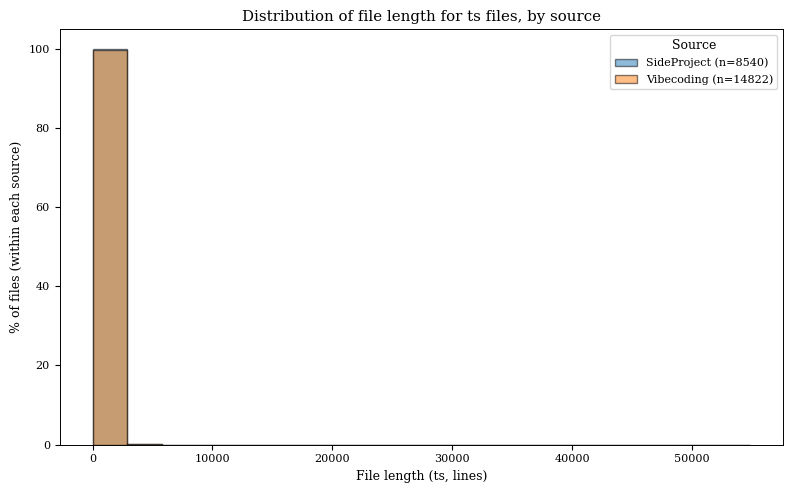

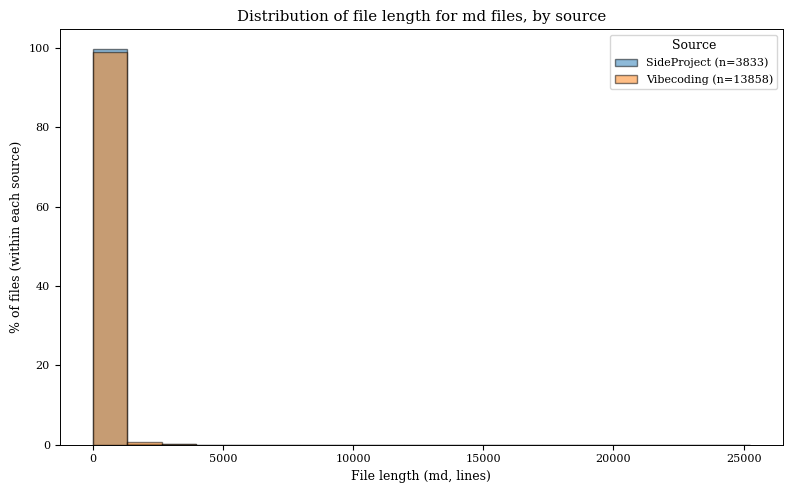

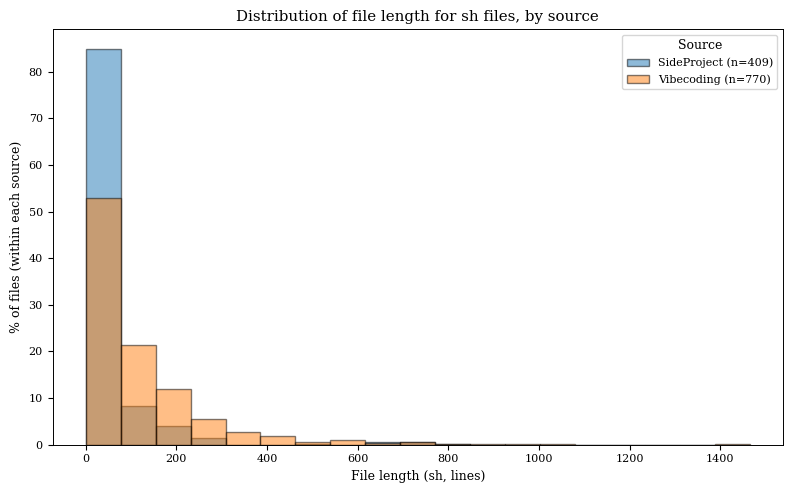

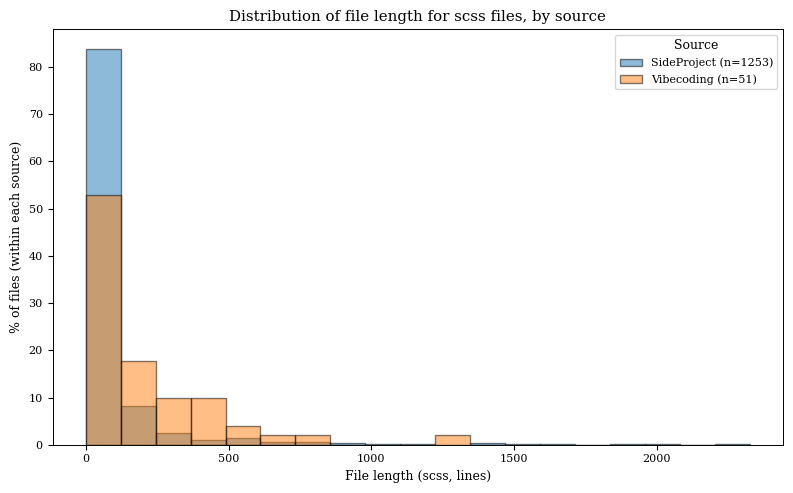

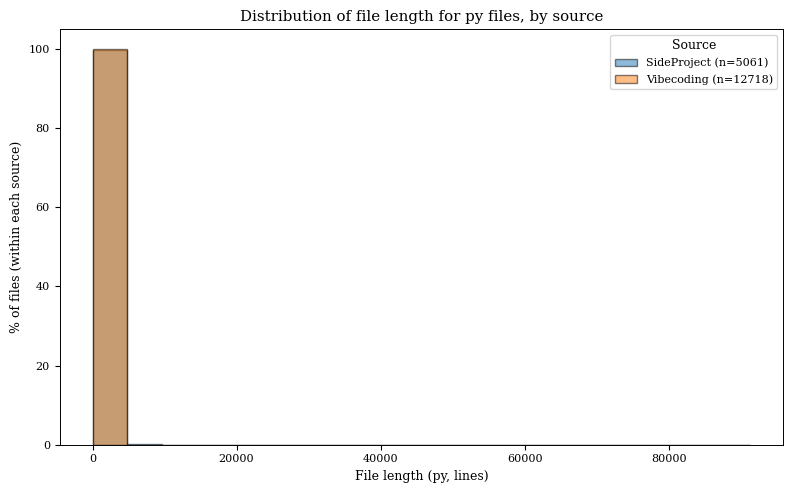

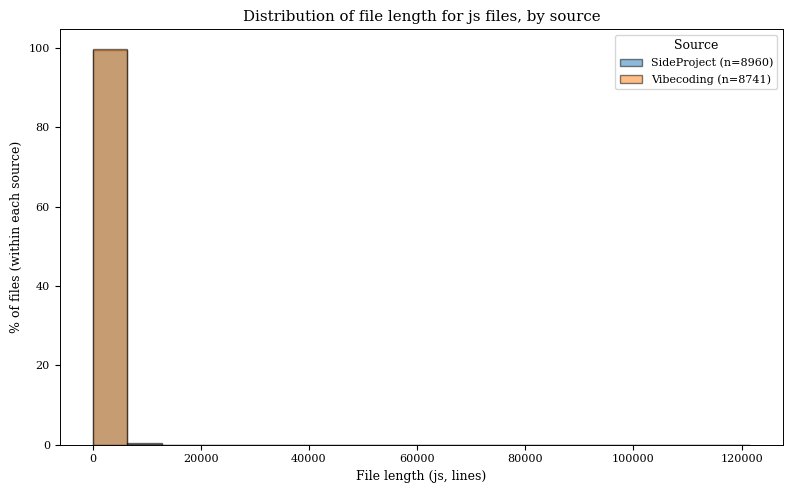

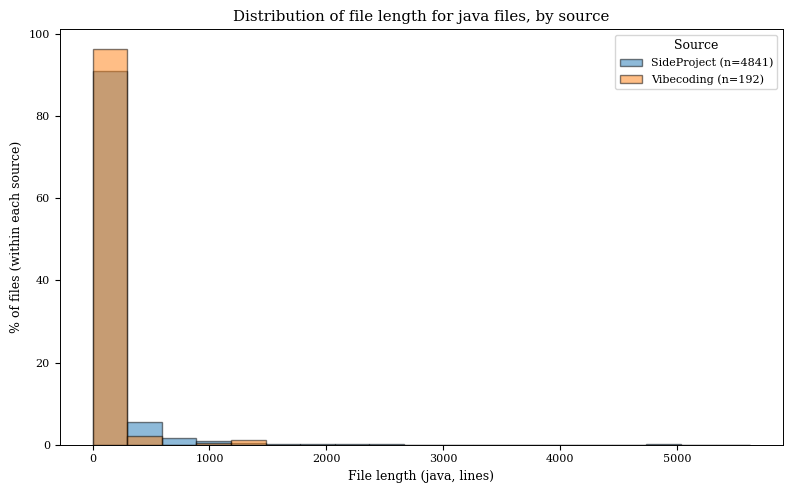

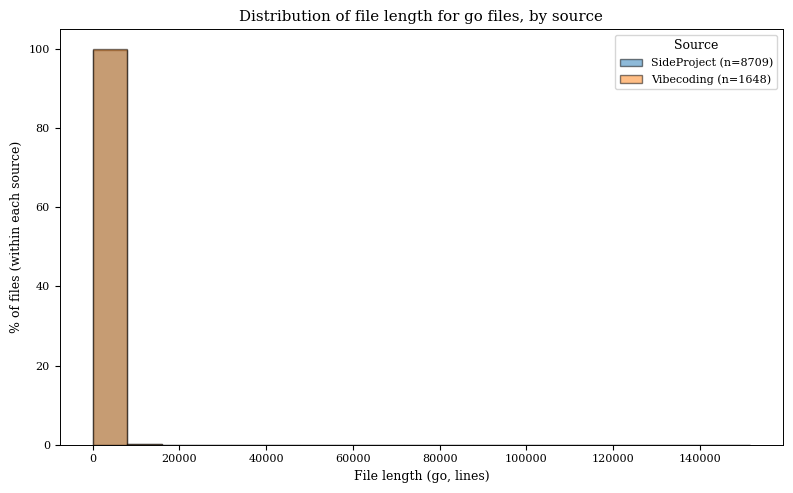

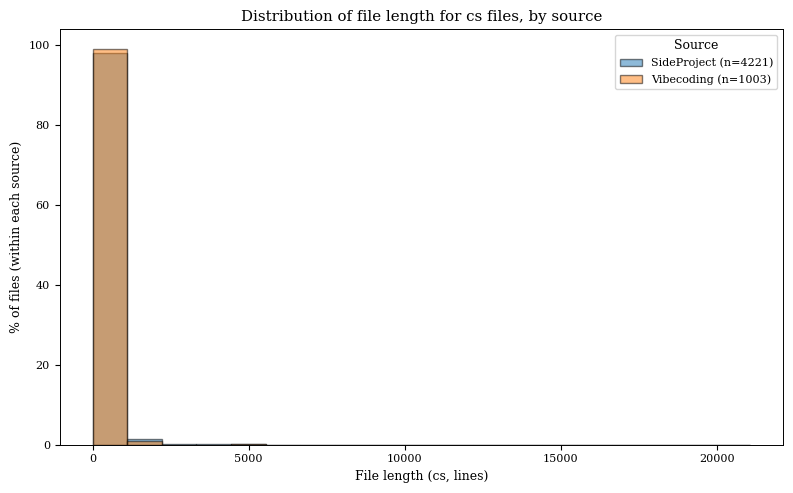

In [148]:
for ext in acceptable_exts:
    df_ext = df_all[df_all["extn"] == ext]

    if df_ext.empty:
        continue

    max_len = df_ext["n_lines"].max()
    min_len = df_ext["n_lines"].min()

    # Linear bins instead of logarithmic bins
    bins = np.linspace(min_len, max_len, 20)

    fig, ax = plt.subplots(figsize=(8, 5))

    for src, group in df_ext.groupby("source"):
        n = len(group)

        # Each source's histogram sums to 100%
        weights = np.full(n, 100 / n)

        ax.hist(
            group["n_lines"],
            bins=bins,
            weights=weights,
            alpha=0.5,
            label=f"{src} (n={n})",
            edgecolor="black"
        )

    # Linear x-axis -- no ax.set_xscale("log")

    ax.set_xlabel(f"File length ({ext}, lines)")
    ax.set_ylabel("% of files (within each source)")
    ax.set_title(
        f"Distribution of file length for {ext} files, by source"
    )

    ax.legend(title="Source")

    plt.tight_layout()
    plt.show()

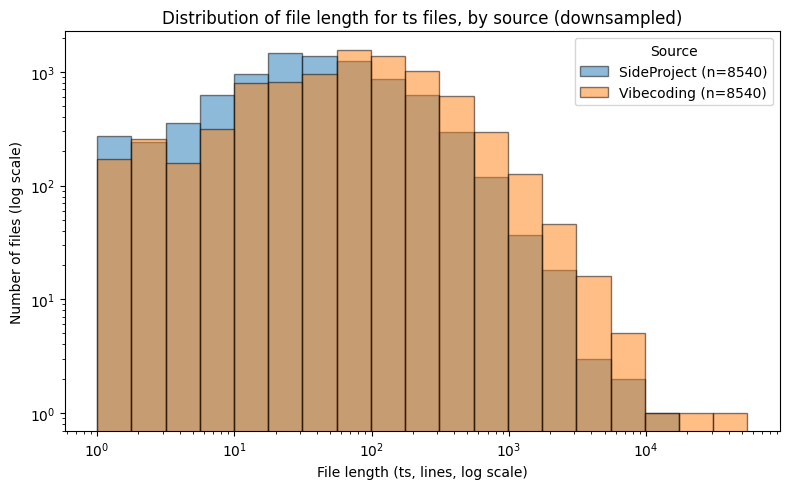

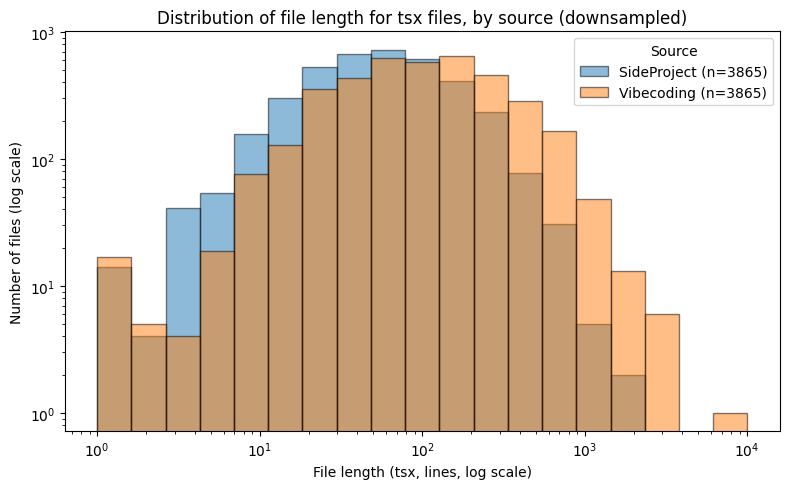

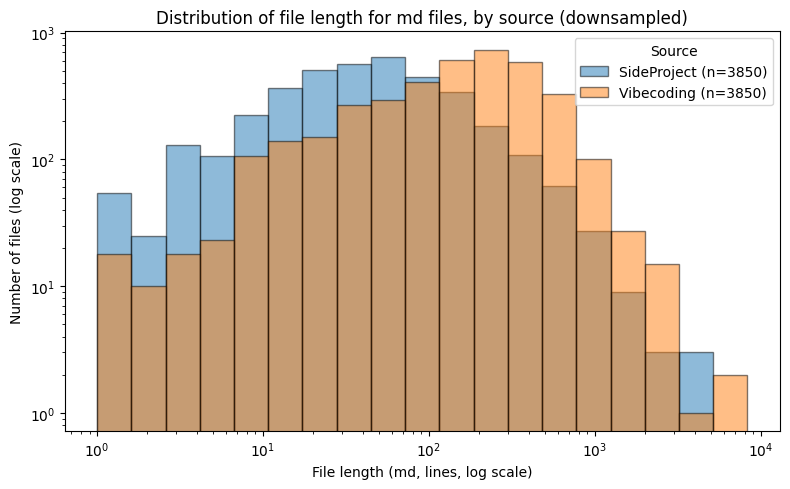

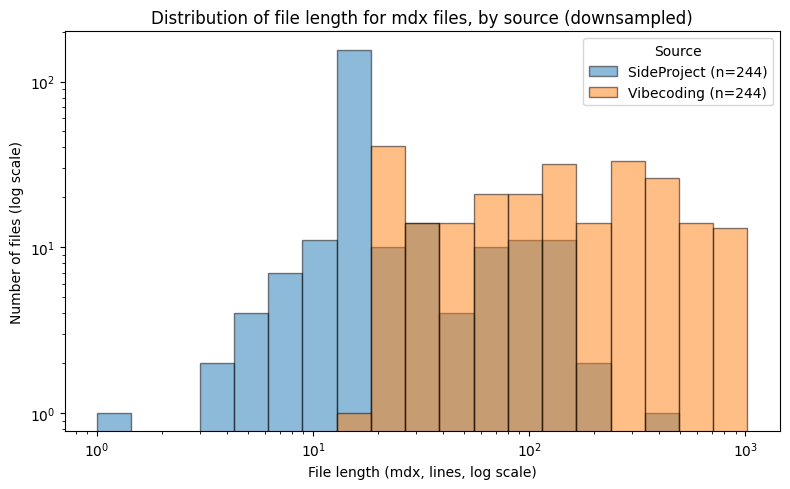

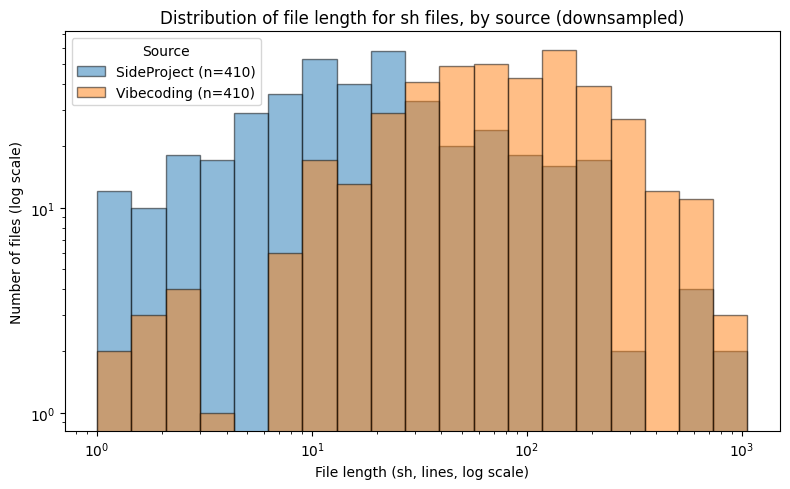

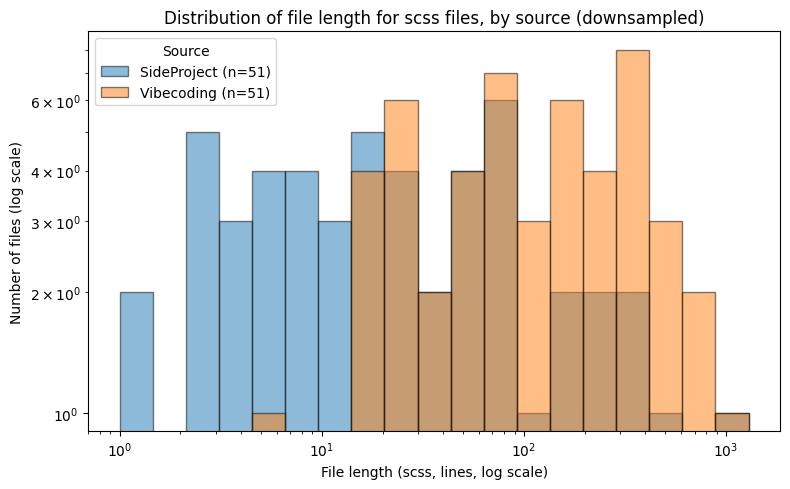

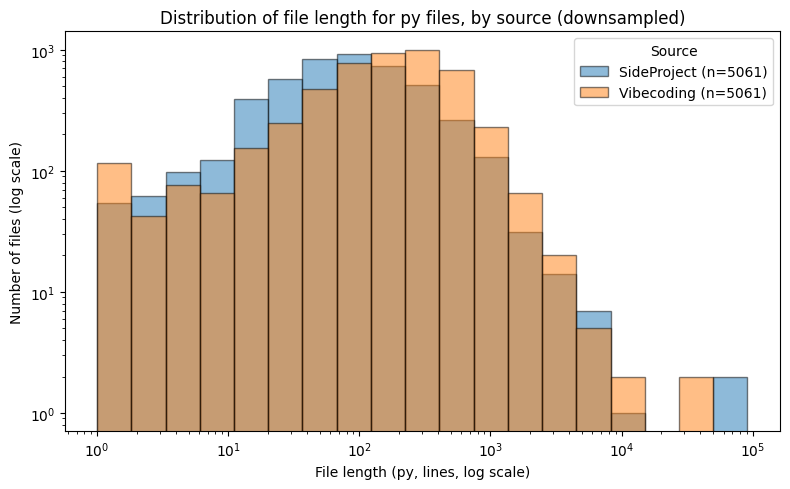

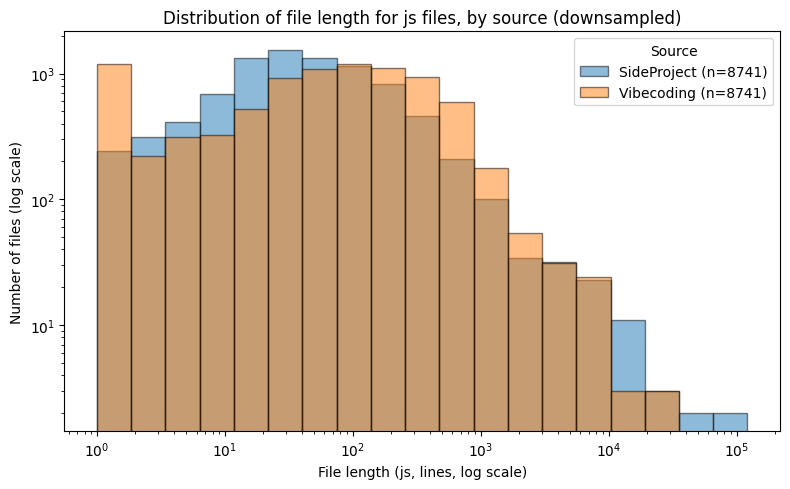

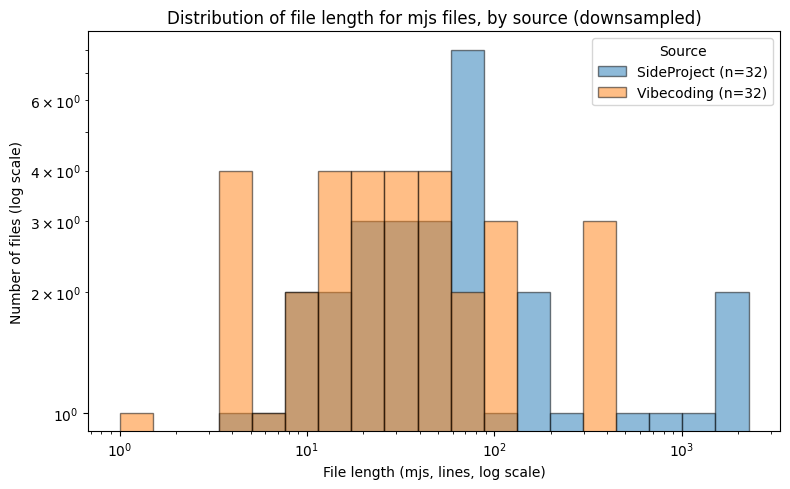

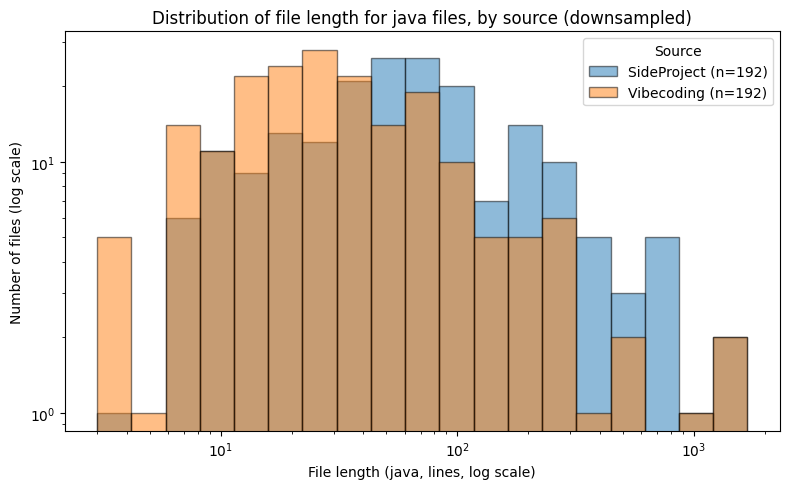

In [33]:


for ext in acceptable_exts:
    df_ext = df_all[df_all["extn"] == ext]

    if df_ext.empty:
        continue

    # Split by source
    groups = {src: g for src, g in df_ext.groupby("source")}

    if len(groups) < 2:
        # Only one source present for this extension — nothing to balance
        balanced_groups = groups
    else:
        min_size = min(len(g) for g in groups.values())
        balanced_groups = {
            src: g.sample(n=min_size, random_state=42) if len(g) > min_size else g
            for src, g in groups.items()
        }

    df_ext_balanced = pd.concat(balanced_groups.values())

    max_len = df_ext_balanced["n_lines"].max()
    min_len = df_ext_balanced["n_lines"].min()

    bins = np.logspace(np.log10(max(min_len, 1)), np.log10(max(max_len, 1)), 20)

    fig, ax = plt.subplots(figsize=(8, 5))

    for src, group in balanced_groups.items():
        n = len(group)
        ax.hist(group["n_lines"], bins=bins, alpha=0.5,
                 label=f"{src} (n={n})", edgecolor="black")

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(f"File length ({ext}, lines, log scale)")
    ax.set_ylabel("Number of files (log scale)")
    ax.set_title(f"Distribution of file length for {ext} files, by source (downsampled)")
    ax.legend(title="Source")
    plt.tight_layout()
    plt.show()

# Percentage of each project the extension accounts for

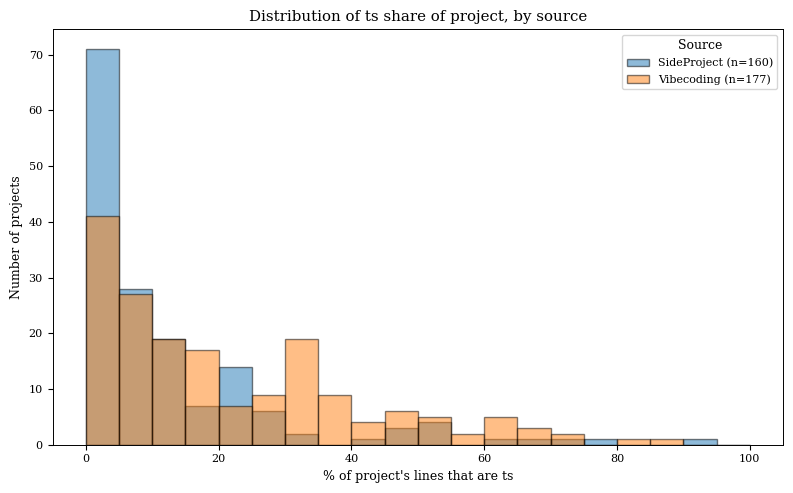

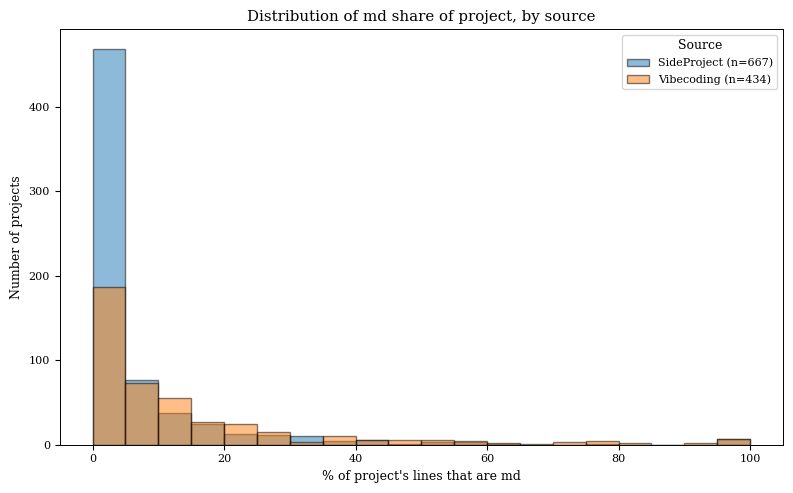

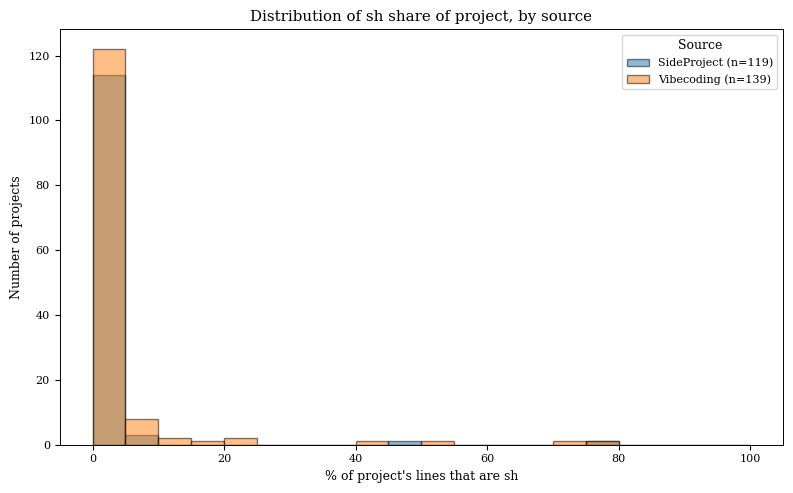

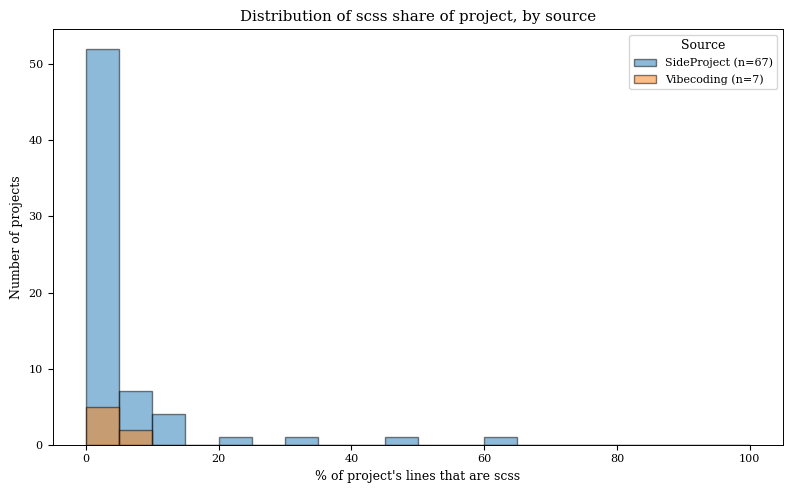

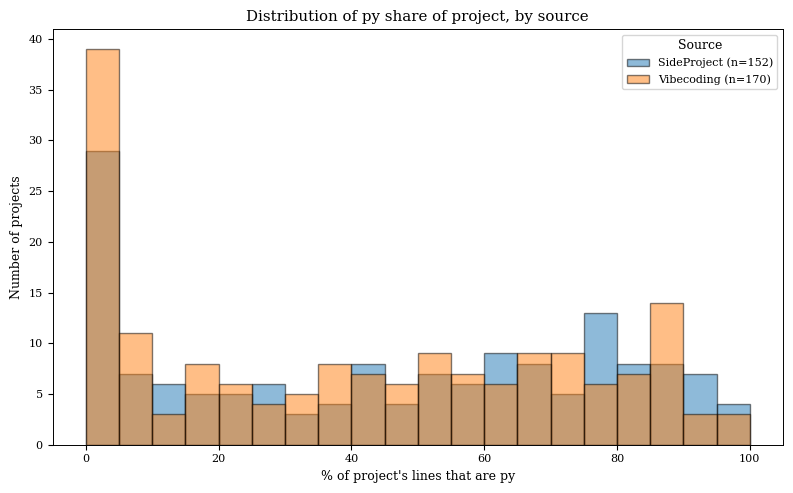

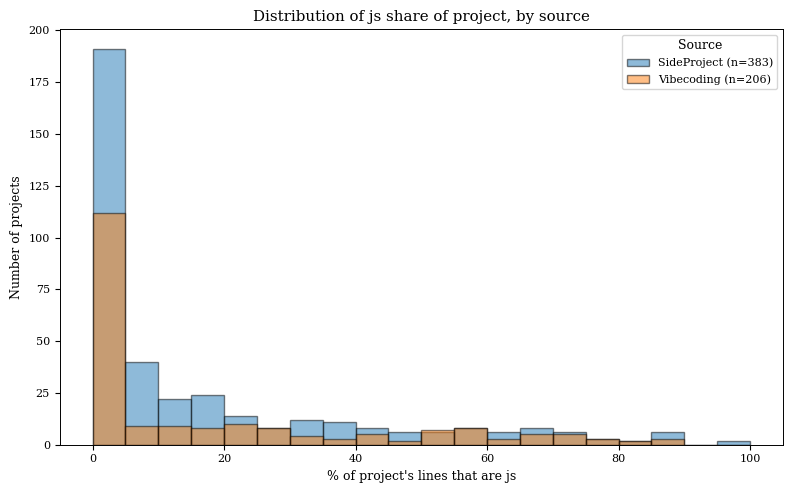

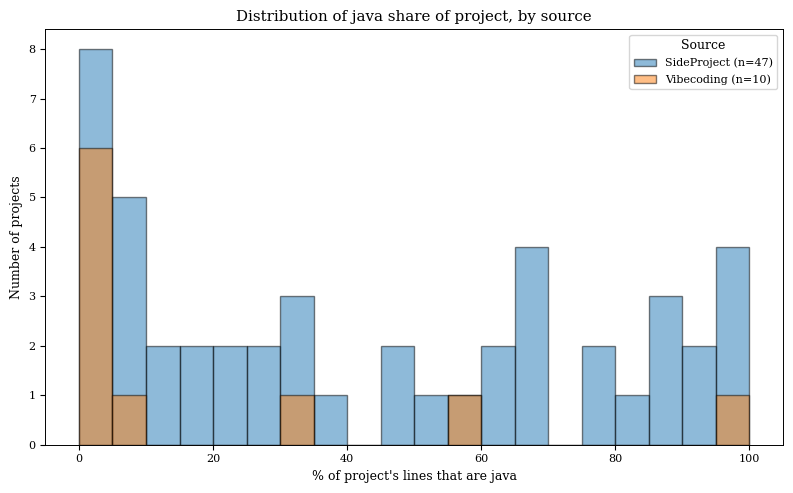

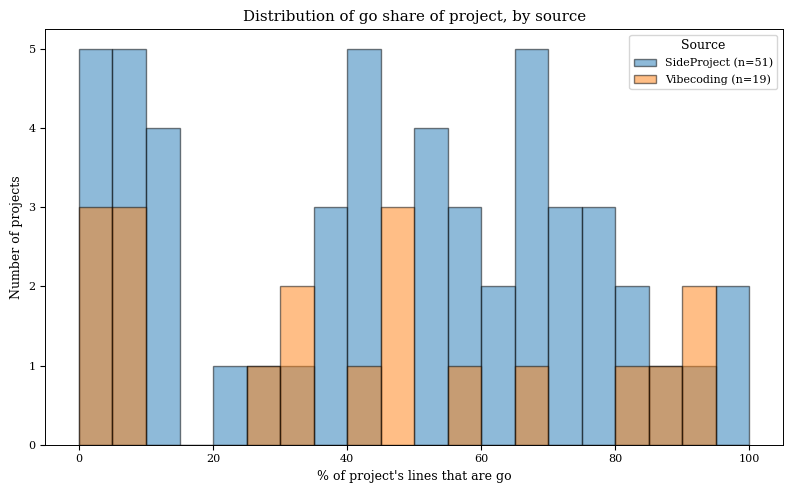

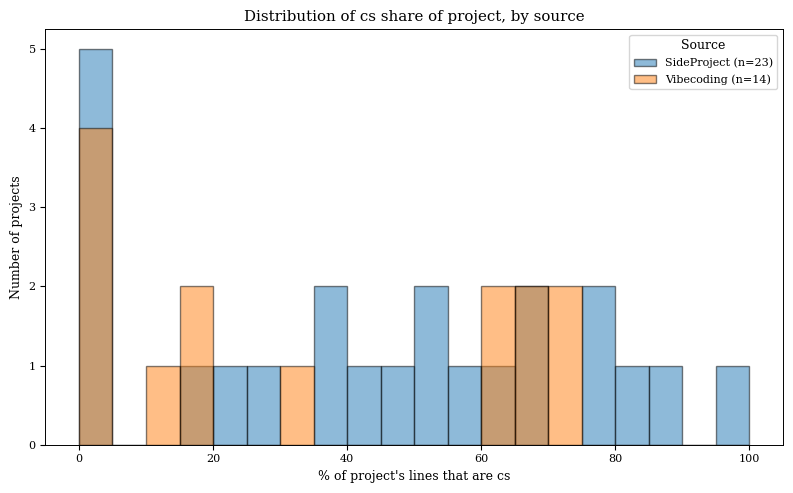

In [137]:

# Total lines per project, across ALL files (the denominator — a project's full size)
total_lines_per_project = df_all.groupby("proj_name")["n_lines"].sum()

for ext in acceptable_exts:
    df_ext = df_all[df_all["extn"] == ext]

    if df_ext.empty:
        continue

    # Lines of this extension per project, per source
    lines_per_ext = df_ext.groupby(["source", "proj_name"])["n_lines"].sum().reset_index(name="ext_lines")

    # Bring in each project's total line count and compute percentage
    lines_per_ext["total_lines"] = lines_per_ext["proj_name"].map(total_lines_per_project)
    lines_per_ext["pct"] = 100 * lines_per_ext["ext_lines"] / lines_per_ext["total_lines"]

    fig, ax = plt.subplots(figsize=(8, 5))

    bins = np.linspace(0, 100, 21)  # 0-100%, 5-point-wide bins

    for src, group in lines_per_ext.groupby("source"):
        n = len(group)
        ax.hist(group["pct"], bins=bins, alpha=0.5,
                 label=f"{src} (n={n})", edgecolor="black")

    ax.set_xlabel(f"% of project's lines that are {ext}")
    ax.set_ylabel("Number of projects")
    ax.set_title(f"Distribution of {ext} share of project, by source")
    ax.legend(title="Source")
    plt.tight_layout()
    plt.show()
    #Want y axis to also be percent

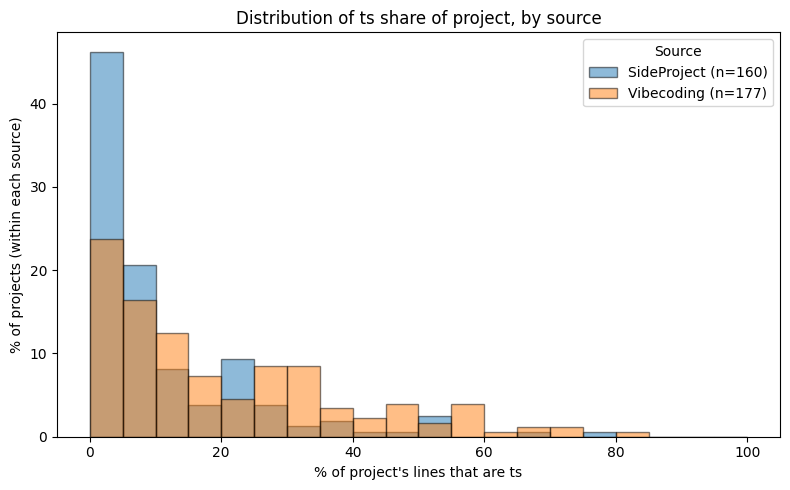

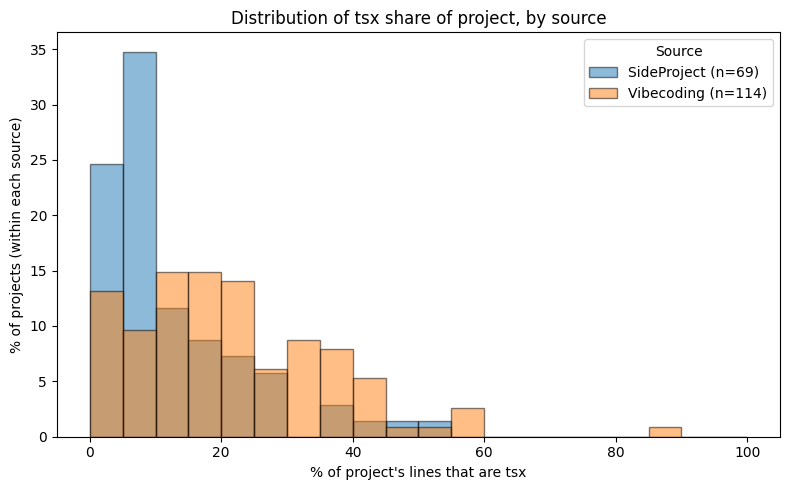

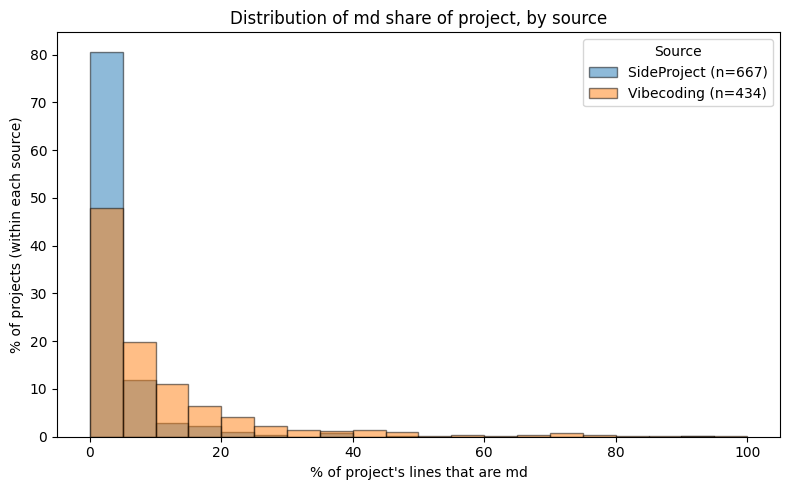

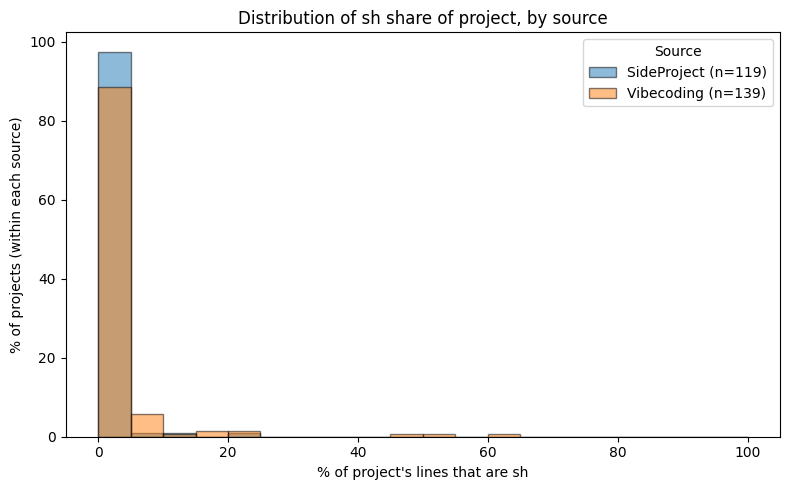

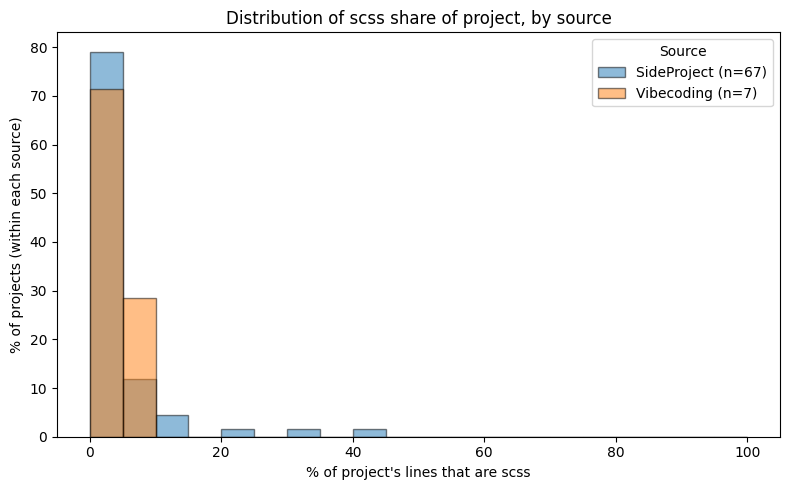

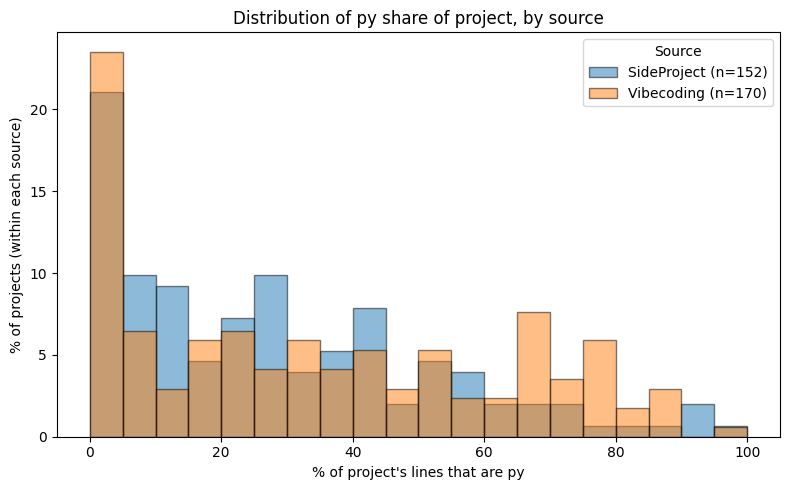

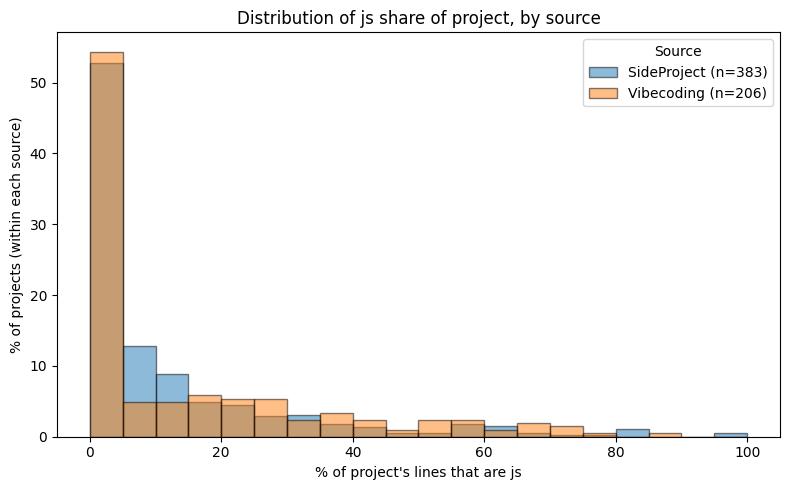

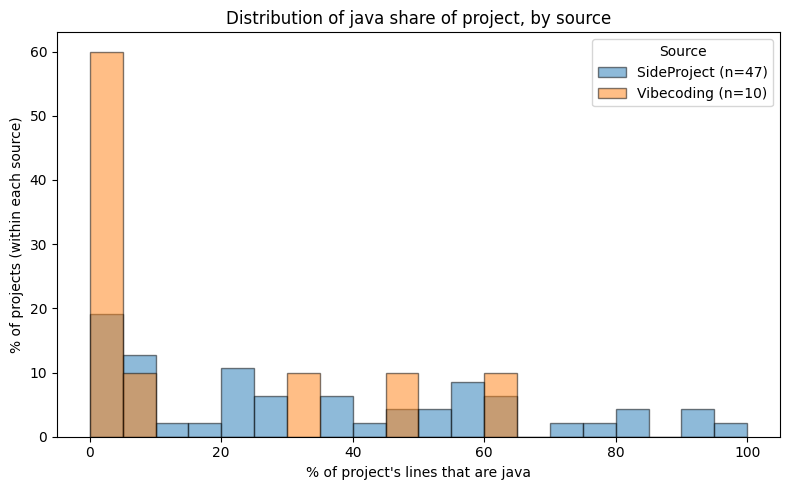

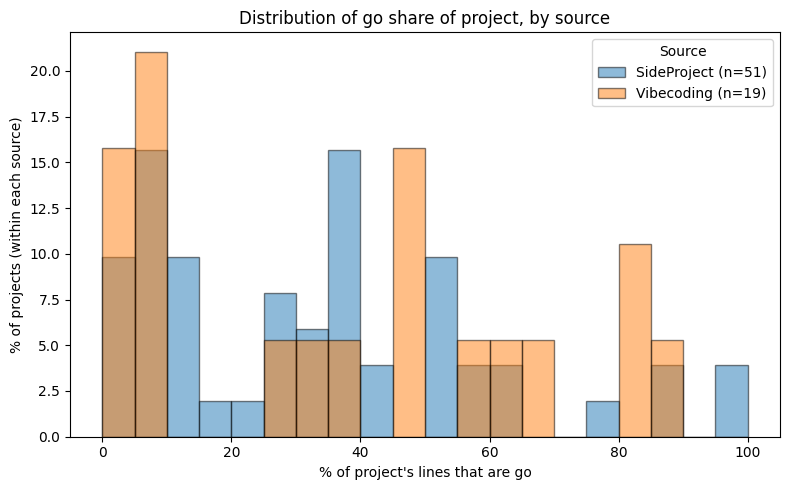

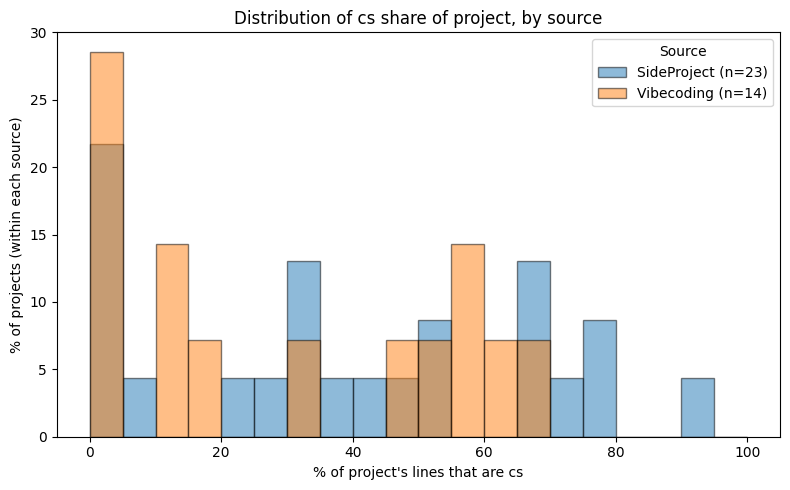

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Total lines per project, across ALL files (the denominator — a project's full size)
total_lines_per_project = df_all.groupby("proj_name")["n_lines"].sum()

for ext in acceptable_exts:
    df_ext = df_all[df_all["extn"] == ext]

    if df_ext.empty:
        continue

    # Lines of this extension per project, per source
    lines_per_ext = df_ext.groupby(["source", "proj_name"])["n_lines"].sum().reset_index(name="ext_lines")

    # Bring in each project's total line count and compute percentage
    lines_per_ext["total_lines"] = lines_per_ext["proj_name"].map(total_lines_per_project)
    lines_per_ext["pct"] = 100 * lines_per_ext["ext_lines"] / lines_per_ext["total_lines"]

    fig, ax = plt.subplots(figsize=(8, 5))

    bins = np.linspace(0, 100, 21)  # 0-100%, 5-point-wide bins

    for src, group in lines_per_ext.groupby("source"):
        n = len(group)
        # weights make each bar sum to 100% across the group, instead of raw counts
        weights = np.full(n, 100 / n)
        ax.hist(group["pct"], bins=bins, weights=weights, alpha=0.5,
                 label=f"{src} (n={n})", edgecolor="black")

    ax.set_xlabel(f"% of project's lines that are {ext}")
    ax.set_ylabel("% of projects (within each source)")
    ax.set_title(f"Distribution of {ext} share of project, by source")
    ax.legend(title="Source")
    plt.tight_layout()
    plt.show()

In [35]:


# Total lines per project (all extensions)
total_lines_per_project = df_all.groupby("proj_name")["n_lines"].sum()

# Lines per (project, extension)
lines_per_proj_ext = df_all.groupby(["proj_name", "extn"])["n_lines"].sum().reset_index()

# For each project, find the row with the max lines (the dominant extension)
idx = lines_per_proj_ext.groupby("proj_name")["n_lines"].idxmax()
dominant = lines_per_proj_ext.loc[idx].copy()

# Compute percentage of the project that extension accounts for
dominant["total_lines"] = dominant["proj_name"].map(total_lines_per_project)
dominant["pct"] = 100 * dominant["n_lines"] / dominant["total_lines"]

dominant = dominant.rename(columns={"extn": "dominant_extn", "n_lines": "dominant_lines"})
dominant = dominant[["proj_name", "dominant_extn", "dominant_lines", "total_lines", "pct"]]
dominant = dominant.sort_values("pct", ascending=False)

for _, row in dominant.iterrows():
    print(f"{row['proj_name']}: {row['dominant_extn']} ({row['pct']:.1f}% of project, "
          f"{row['dominant_lines']}/{row['total_lines']} lines)")

JS-OS: js (99.5% of project, 327076/328805 lines)
Open-Lowcode: java (99.2% of project, 187318/188904 lines)
fts-actors: txt (99.1% of project, 128263/129440 lines)
adaptive: json (98.9% of project, 4698223/4752404 lines)
NMBS-Train-data: html (97.6% of project, 260803/267189 lines)
ir-remote-backend: go (97.2% of project, 328945/338588 lines)
landmine: js (96.5% of project, 24388/25270 lines)
contestsatvit: json (96.5% of project, 31420/32564 lines)
webhook: go (96.4% of project, 274466/284860 lines)
BballApp: json (96.2% of project, 281395/292396 lines)
grocerytimer-tracker: sample (96.2% of project, 791/822 lines)
Wikipedia-Text-Formatter: json (96.2% of project, 30768/31996 lines)
Motivation-Nation-: sample (96.1% of project, 791/823 lines)
mudcrawler: py (95.7% of project, 23640/24694 lines)
OpenManus: sample (95.6% of project, 791/827 lines)
Hashnode-App: json (95.5% of project, 19879/20821 lines)
PRPs-agentic-eng: md (95.4% of project, 43244/45317 lines)
http-rider: py (95.3% of

In [52]:

# Total number of files per project (all extensions)
df_some = df_all[~df_all["extn"].isin(["sample", "HEAD"])]
total_files_per_project = df_some.groupby("proj_name").size()

# Number of files per (project, extension)
files_per_proj_ext = df_some.groupby(["proj_name", "extn"]).size().reset_index(name="n_files")

# For each project, find the row with the max file count (the dominant extension)
idx = files_per_proj_ext.groupby("proj_name")["n_files"].idxmax()
dominant = files_per_proj_ext.loc[idx].copy()

# Compute percentage of the project's files that extension accounts for
dominant["total_files"] = dominant["proj_name"].map(total_files_per_project)
dominant["pct"] = 100 * dominant["n_files"] / dominant["total_files"]

dominant = dominant.rename(columns={"extn": "dominant_extn"})
dominant = dominant[["proj_name", "dominant_extn", "n_files", "total_files", "pct"]]
dominant = dominant.sort_values("pct", ascending=False)

for _, row in dominant.iterrows():
    print(f"{row['proj_name']}: {row['dominant_extn']} ({row['pct']:.1f}% of project, "
          f"{row['n_files']}/{row['total_files']} files)")

COVID-19: csv (98.7% of project, 5093/5159 files)
Amazon-SES-Directadmin-Hook: php (98.4% of project, 1610/1636 files)
Open-Lowcode: java (97.5% of project, 1077/1105 files)
cards2.0: java (95.6% of project, 416/435 files)
JS-OS: js (93.1% of project, 430/462 files)
Poker-Hand-Tracker: py (92.0% of project, 127/138 files)
brainless.in: md (90.5% of project, 474/524 files)
RasaTalk: js (88.4% of project, 524/593 files)
PRPs-agentic-eng: md (87.7% of project, 136/155 files)
chunkhound: py (86.6% of project, 606/700 files)
noderr: md (84.8% of project, 39/46 files)
chartbrew: js (84.4% of project, 662/784 files)
robot-dreams: py (84.3% of project, 70/83 files)
youtubeScrobbler: js (84.1% of project, 174/207 files)
Camelot: cs (82.8% of project, 681/822 files)
gsoc-tagger: py (82.6% of project, 976/1182 files)
ir-remote-backend: go (82.5% of project, 706/856 files)
ShadcnVaults: tsx (82.1% of project, 142/173 files)
GitMind: go (81.9% of project, 68/83 files)
croma-react: hpp (81.6% of pro

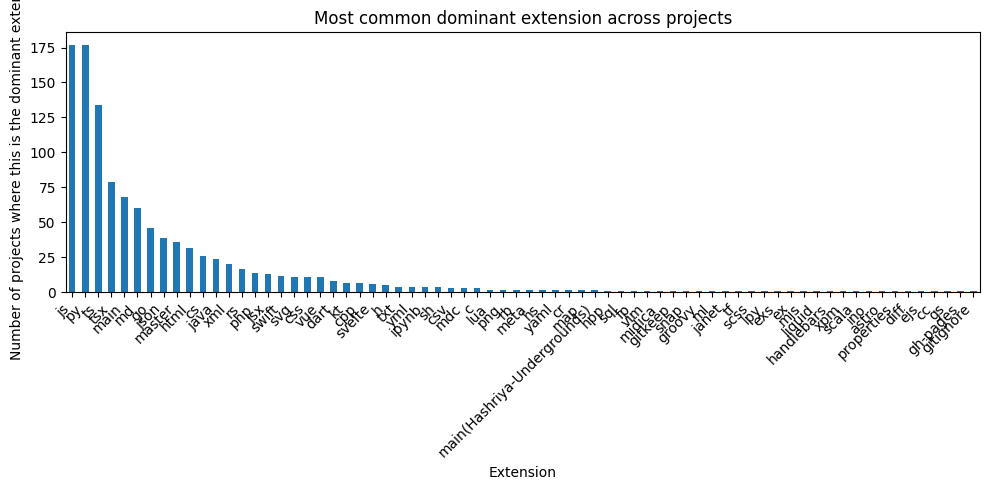

In [53]:


# Count how many projects have each extension as their dominant one
dominant_counts = dominant["dominant_extn"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
dominant_counts.plot(kind="bar", ax=ax)

ax.set_xlabel("Extension")
ax.set_ylabel("Number of projects where this is the dominant extension")
ax.set_title("Most common dominant extension across projects")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
#add go and cs to dataset

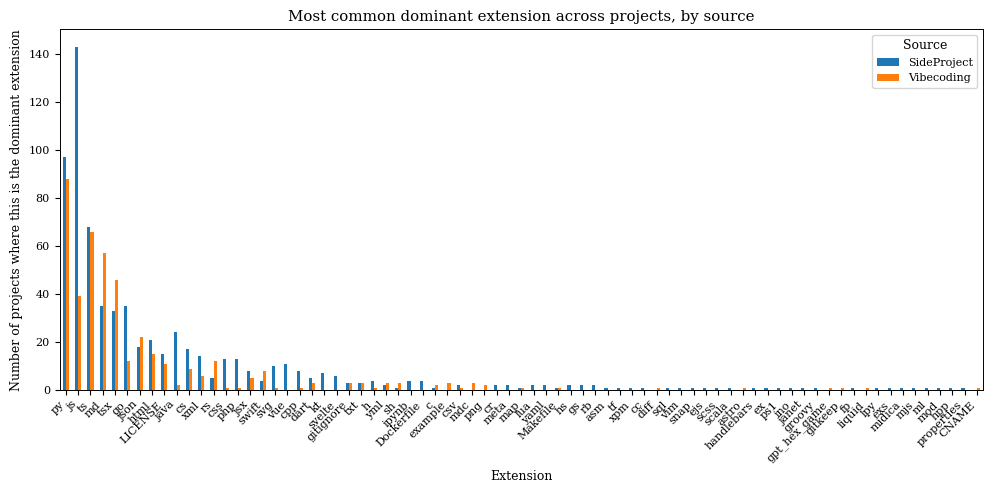

In [143]:
import pandas as pd
import matplotlib.pyplot as plt

# Total number of files per project, per source
df_some = df_all[~df_all["extn"].isin(["sample", "HEAD"])]
total_files_per_proj_source = df_some.groupby(["proj_name", "source"]).size()

# Number of files per (project, source, extension)
files_per_proj_source_ext = df_some.groupby(["proj_name", "source", "extn"]).size().reset_index(name="n_files")

# For each (project, source), find the row with the max file count
idx = files_per_proj_source_ext.groupby(["proj_name", "source"])["n_files"].idxmax()
dominant_by_source = files_per_proj_source_ext.loc[idx].copy()

dominant_by_source = dominant_by_source.rename(columns={"extn": "dominant_extn"})

# Count how many (project, source) combos have each extension as dominant, split by source

dominant_counts = dominant_by_source.groupby(["dominant_extn", "source"]).size().unstack(fill_value=0)
# dominant_counts["pct"] = 100 * dominant_counts["dominant_extn"] / dominant_counts["total_lines"]
dominant_counts = dominant_counts.loc[dominant_counts.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(10, 5))
dominant_counts.plot(kind="bar", ax=ax)

ax.set_xlabel("Extension")
ax.set_ylabel("Number of projects where this is the dominant extension")
ax.set_title("Most common dominant extension across projects, by source")
ax.legend(title="Source")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

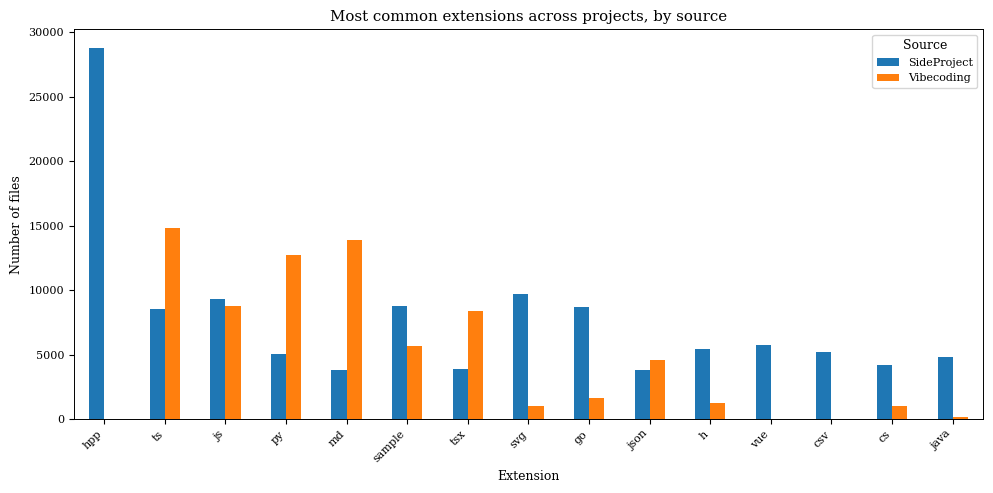

In [144]:
import pandas as pd
import matplotlib.pyplot as plt

# Count number of files per extension, split by source
extn_counts = extn_counts.loc[extn_counts.sum(axis=1).sort_values(ascending=False).index].head(15)

# Sort by total count across both sources, descending
extn_counts = extn_counts.loc[extn_counts.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 5))
extn_counts.plot(kind="bar", ax=ax)

ax.set_xlabel("Extension")
ax.set_ylabel("Number of files")
ax.set_title("Most common extensions across projects, by source")
ax.legend(title="Source")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

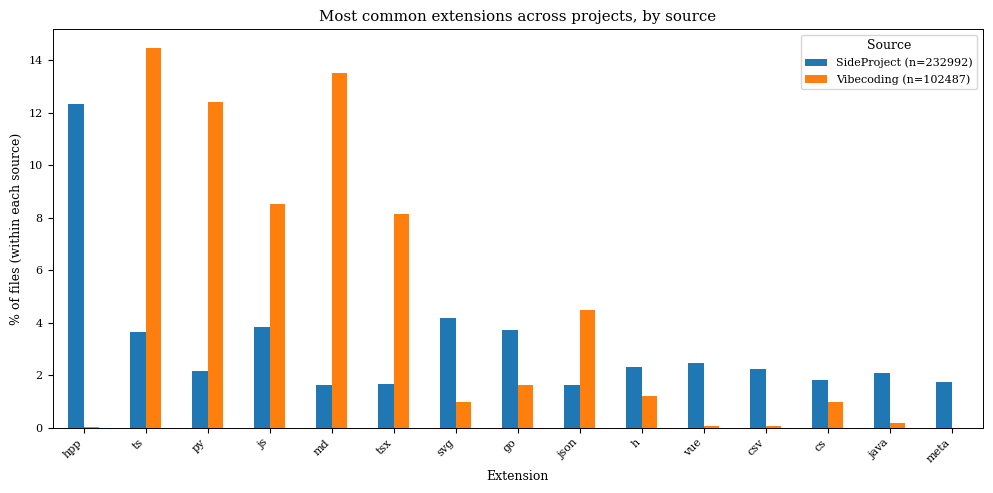

In [145]:
import pandas as pd
import matplotlib.pyplot as plt

# Count number of files per extension, split by source
extn_counts = df_all.groupby(["extn", "source"]).size().unstack(fill_value=0)

# Sort by total count across both sources, descending, and keep top 15
extn_counts = extn_counts.loc[extn_counts.sum(axis=1).sort_values(ascending=False).index].head(15)

# Total number of files per source (denominator for percentages)
total_files_per_source = df_all.groupby("source").size()

# Convert to percentage of that source's total files
pct = extn_counts.div(total_files_per_source, axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 5))
pct.plot(kind="bar", ax=ax)

# Label each bar with the raw file count
# for container, col in zip(ax.containers, extn_counts.columns):
#     ax.bar_label(container, labels=[f"n={v}" for v in extn_counts[col].values], padding=2, fontsize=8)

ax.set_xlabel("Extension")
ax.set_ylabel("% of files (within each source)")
ax.set_title("Most common extensions across projects, by source")
ax.legend(title="Source", labels=[f"{col} (n={total_files_per_source[col]})" for col in pct.columns])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Get the failed files code from the project level one

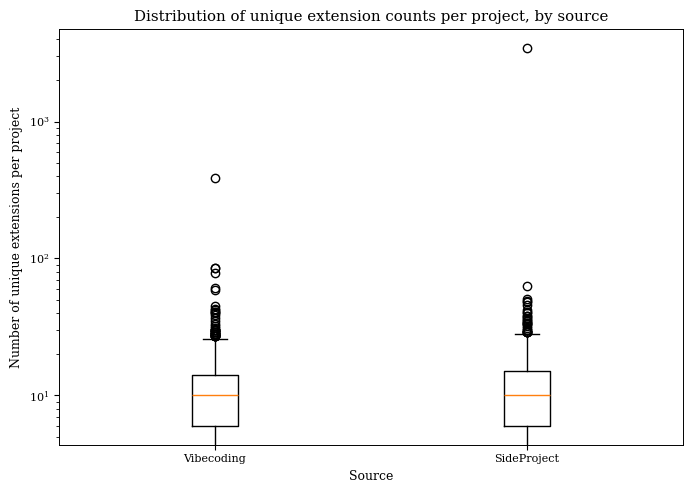

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
# df_merged_all

# Number of unique extensions per project, per source
unique_extns = df_merged_all.groupby(["proj_name", "source"])["extn"].nunique().reset_index(name="n_unique_extns")

# Split into two groups by source
groups = [group["n_unique_extns"].values for _, group in unique_extns.groupby("source")]
labels = unique_extns["source"].unique()

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(groups, tick_labels=labels)
ax.set_yscale("log")

ax.set_xlabel("Source")
ax.set_ylabel("Number of unique extensions per project")
ax.set_title("Distribution of unique extension counts per project, by source")
plt.tight_layout()
plt.show()

In [22]:
unique_extns.groupby("source")["n_unique_extns"].describe()

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
SideProject,681.0,12.162996,16.824042,0.0,6.0,10.0,14.0,384.0
Vibecoding,446.0,19.721973,162.090359,0.0,6.0,10.0,15.0,3430.0


In [23]:
unique_extns.groupby("source")["n_unique_extns"].median()

source
SideProject    10.0
Vibecoding     10.0
Name: n_unique_extns, dtype: float64

In [24]:
doom_list = ['jpg', 'sample', 'png', 'pack',  'svg',  'gif', 'wav', 'webp', 'glb',  'ico',  'map' , 'lock',  'pdf', 
             'jpeg',  'mts', 'scene',   'icns',  'mp4', 'ogg', 'pro', 'mod', 'tar', 'fbx',  'lockb',  'mp3', 'zip', 
             'obj',  'pxd', 'sq',  'standalone',  'vue', 'm4', 'milk',  'bmp', 'dfm',  'xpm', 'gz', 'rar', 'srt',  
             'au', 'ai', 'l',  'tgz',   'x' , 'y', '~dfm', '~63~', '~30~', '~31~', '~32~',  '~33~', '~34~', '~35~', 
             '~36~', '~37~', '~38~', '~39~', '~56~', '~57~', '~58~', '~59~', '~60~', '~61~', '~62~',  '~64~', '~65~',  
             'catalog',  'frx', 'def', 'hdr', 'mkv', 'otf', 'p', 'psd', 'smi', 'sofa',  'thumbnailer',  'voc', 'tiff' , 
             'vsp' , 'asset','json', 'csv', 'HEAD', 'zon', 'meta', 'gitignore', 'LICENSE']

lang_list = ['ts',  'tsx', 'markdown', 'md', 'mdx',  'xml', 'cs', 'py',  'js', 'mjs',  'cjs',  'ejs',  'rs',  'css', 
             'kt', 'html', 'sh',  'txt',  'sql',  'astro',  'go', 'c', 'cc',  'cpp',  'hpp', 'csproj',  'm',  'h', 
             'rb', 'tmlanguage', 'java', 'swift',  'ru', 'ipynb',  'bat',  'exe',  'kts', 'wasm',  'npmrc',  'nvmrc',  
             'sb',  'snap', 'http', 'ps1',  'php',  'woff2', 'sum', 'mako',  'ino',  'cmd',  'env', 'ahk',  'bash',  
             'erb', 'onnx',  'server', 'skill',  'tpl',  'class',  'mak', 'mk', 'lua', 's', 'dcu', 'less',  'pas',  
             'woff', 'scss', 'pyc', 'dpr', 'inc', 'res',  'resx',  'dproj',  'hex',  'idl',  'pl', 'bm2', 'dak',  
             'gradle',  'ld',  'rst' , 'wxs', 'bsd',  'el', 'htaccess',  'manifest', 'md~',  'vcxproj', '~pas',  
             'ap_',  'asm',  'bas',  'classpath',  'ddp',  'dex' , 'dist', 'htm',  'lircrc',  'makefile',  'odt', 
             'qml',  'qrc',  'rtf', 'sass', 'sch',  'skins2', 'tmpl', 'vbp', 'vbw',  'vim' , 'xsd', '~ddp', '~dpr', ]

lang_dict = {'ts': 'typescript', 'tsx':'typescript', 
             'markdown':'markdown', 'md':'markdown', 'mdx':'markdown', 'xml':'markdown', 'manifest':'markdown', 'md~':'markdown', 'htm':'markdown', 'qrc':'markdown',  'xsd':'markdown',
             'txt':'text',  'rst':'text', 'odt':'text',  'rtf':'text',
             'c':'C', 'm':'C',
             'cs':'C#',  'csproj':'C#',
             'cc':'C++', 'cpp':'C++', 'hpp':'C++', 'vcxproj':'C++',
              'py': 'Python', 'ipynb':'Python Notebook',  '.mako':'Python', 
             'js':'JavaScript', 'mjs':'JavaScript', 'cjs':'JavaScript', 'ejs':'JavaScript',  'astro':'JavaScript',
             'java':'Java', 'class':'Java',
             'rs': 'Rust',
             'css':'CSS', 'less':'CSS',  'scss':'CSS', 'sass':'CSS',
             'html': 'HTML',
             'http':'HTTP',
             'kt':'Kotlin', 'kts':'Kotlin',
             'sh':'Shell', 'bat':'Shell', 'exe':'Shell', 'ps1':'Shell', 'cmd':'Shell', 'ahk':'Shell', 'bash':'Shell', 'ld':'Shell',  'asm':'Shell', 'lircrc':'Shell',
             'sql':'SQL',  'server':'SQL',
             'go':'GO',
             'rb':'Ruby',  'erb':'Ruby',
             'swift':'Swift',
             'wasm':'Assembly', 's':'Assembly',
             'sb':'Scratch',
             'php':'Php',
             'woff2':'Web Open Front Format',  'woff':'Web Open Front Format',
             'sum':'Scilab',
             'ino':'Arduino',
             'skill':'Skill',
             'onnx':'Onnx',
             'tpl':'Template', 'inc':'Template', 'h':'Template', 'idl':'Template', 'classpath':'Template', 'tmpl':'Template',
             'mak':'Makefile', 'mk':'Makefile', 'makefile':'Makefile',
             'lua':'Lua',
             'dcu':'Delphi', 'pas':'Delphi', 'dpr':'Delphi', 'dproj':'Delphi', '~pas':'Delphi', 'ddp':'Delphi', '~ddp':'Delphi', '~dpr':'Delphi',
             'pyc':'Bytecode', 'hex':'Bytecode',
             'pl':'Perl',
             'bm2':'Boardmaker Interactive Board File',
             'dak':'Debian Archive Kit Data',
             'gradle':'Gradle',
             'bsd':'BSDL',
             'el':'LSP',
             'ap_':'Pascal',
             'bas':'Basic', 'vbp':'Basic',
             'dex':'Dalvik',
             'qml':'Qt SDK',
             'sch':'Circuitry',
             'skins2':'Skins',
             'tmlanguage':'Other', 'ru':'Other', 'snap':'Other',  'env':'Other', 'res':'Other','npmrc':'Other',  'nvmrc':'Other', 'resx':'Other', 'wxs':'Other', 'htaccess':'Other', 'dist':'Other', 'vbw':'Other',  'vim':'Other'
             
            }

In [28]:
new_unique_extns = df_merged_all[~df_merged_all["extn"].isin(doom_list)]
new_new_unique_extns = new_unique_extns.groupby(["proj_name", "source"])["extn"].nunique().reset_index(name="n_unique_extns")

In [29]:
new_new_unique_extns.groupby("source")["n_unique_extns"].describe()

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
SideProject,681.0,9.339207,16.387883,0.0,4.0,7.0,11.00,381.0
Vibecoding,446.0,16.901345,161.558155,0.0,4.0,7.0,11.75,3417.0


In [30]:
new_new_unique_extns.groupby("source")["n_unique_extns"].median()

source
SideProject    7.0
Vibecoding     7.0
Name: n_unique_extns, dtype: float64

In [34]:
new_unique_extns["language"] = new_unique_extns["extn"].map(
    lambda ext: lang_dict.get(ext, ext)
)

In [35]:
new_unique_extns.head()

,url,proj_name,file_path,reason,source,file_name,extn,n_lines,blank_lines,char,language
0,https://github.com/Skowt/Loadr,Loadr,Loadr/img/icon.png,failed reading file: 'utf-8' codec can't decod...,SideProject,NaN,NaN,NaN,NaN,NaN,NaN
1,https://github.com/Skowt/Loadr,Loadr,Loadr/img/glyphicons-halflings.png,failed reading file: 'utf-8' codec can't decod...,SideProject,NaN,NaN,NaN,NaN,NaN,NaN
2,https://github.com/Skowt/Loadr,Loadr,Loadr/img/glyphicons-halflings-white.png,failed reading file: 'utf-8' codec can't decod...,SideProject,NaN,NaN,NaN,NaN,NaN,NaN
3,https://github.com/AI-Spawn/Save-The-Turtles,Save-The-Turtles,Save-The-Turtles/.DS_Store,failed reading file: 'utf-8' codec can't decod...,SideProject,NaN,NaN,NaN,NaN,NaN,NaN
4,https://github.com/AI-Spawn/Save-The-Turtles,Save-The-Turtles,Save-The-Turtles/obj/Debug/Assembly-CSharp.dll,failed reading file: 'utf-8' codec can't decod...,SideProject,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df_merged_all.columns

Index(['url', 'proj_name', 'file_path', 'reason', 'source', 'file_name',
       'extn', 'n_lines', 'blank_lines', 'char'],
      dtype='str')

In [105]:
total_lines_per_project = df_all.groupby(["proj_name", "source"])["n_lines"].sum()
print(total_lines_per_project.groupby("source").median())

source
SideProject     8140.0
Vibecoding     13699.0
Name: n_lines, dtype: float64


# Percentage of Projects outside 9 most common extension

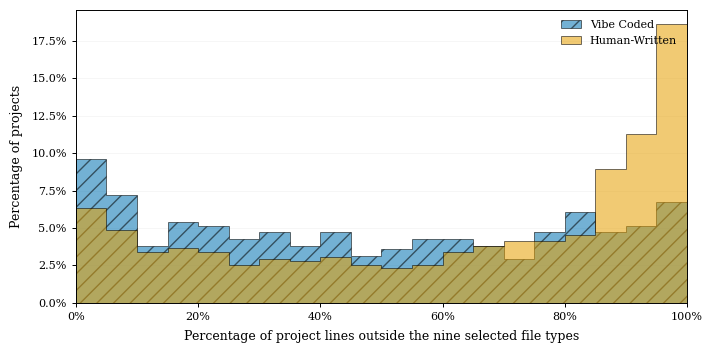

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch


# ---------------------------------------------------------
# Calculate percentage of lines outside the nine file types
# for each project
# ---------------------------------------------------------

# Total lines in each project across ALL file types
project_totals = (
    df_all
    .groupby(["source", "proj_name"])["n_lines"]
    .sum()
    .reset_index(name="total_lines")
)

# Total lines in each project belonging to the nine
# file types in acceptable_exts
selected_lines = (
    df_all[
        df_all["extn"].isin(acceptable_exts)
    ]
    .groupby(["source", "proj_name"])["n_lines"]
    .sum()
    .reset_index(name="selected_lines")
)

# Merge so projects with none of the nine types are retained
project_pct = project_totals.merge(
    selected_lines,
    on=["source", "proj_name"],
    how="left"
)

# A project with none of the selected types has 0 selected lines
project_pct["selected_lines"] = (
    project_pct["selected_lines"]
    .fillna(0)
)

# Lines belonging to all OTHER file types
project_pct["other_lines"] = (
    project_pct["total_lines"]
    - project_pct["selected_lines"]
)

# Percentage of project lines outside the nine file types
project_pct["pct_other"] = (
    100
    * project_pct["other_lines"]
    / project_pct["total_lines"]
)


# ---------------------------------------------------------
# Publication formatting
# ---------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.2, 3.6)
)

# 5-percentage-point bins
bins = np.linspace(
    0,
    100,
    21
)

# Same colors/encoding as previous figures
source_styles = {
    "Vibecoding": {
        "color": "#0072B2",
        "hatch": "//",
        "label": "Vibe Coded"
    },
    "SideProject": {
        "color": "#E69F00",
        "hatch": "",
        "label": "Human-Written"
    }
}

# colors = [
#     "#0072B2",   # Vibe Coded
#     "#E69F00"    # Human-Written
# ]


# ---------------------------------------------------------
# Draw histogram for each source
# ---------------------------------------------------------

for source in ["Vibecoding", "SideProject"]:

    group = project_pct[
        project_pct["source"] == source
    ]

    # Each group's histogram sums to 100%.
    # Therefore the y-axis represents percentage of projects,
    # rather than raw project count.
    weights = (
        np.ones(len(group))
        * 100
        / len(group)
    )

    style = source_styles[source]

    ax.hist(
        group["pct_other"],
        bins=bins,
        weights=weights,
        histtype="stepfilled",
        facecolor=style["color"],
        edgecolor="black",
        hatch=style["hatch"],
        alpha=0.55,
        linewidth=0.7,
        label=style["label"]
    )


# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------

ax.set_xlabel(
    "Percentage of project lines outside the nine selected file types",
    labelpad=6
)

ax.set_ylabel(
    "Percentage of projects",
    labelpad=6
)

# x values are already 0-100
ax.xaxis.set_major_formatter(
    PercentFormatter(100)
)

# y values are already percentages
ax.yaxis.set_major_formatter(
    PercentFormatter(100)
)

ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)


# ---------------------------------------------------------
# Grid and frame
# ---------------------------------------------------------

ax.grid(
    axis="y",
    linewidth=0.4,
    alpha=0.20,
    zorder=0
)

ax.grid(
    axis="x",
    visible=False
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(0.7)

ax.tick_params(
    axis="both",
    direction="out",
    length=3,
    width=0.7
)


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

legend_handles = [
    Patch(
        facecolor="#0072B2",
        edgecolor="black",
        hatch="//",
        alpha=0.55,
        linewidth=0.7,
        label="Vibe Coded"
    ),
    Patch(
        facecolor="#E69F00",
        edgecolor="black",
        alpha=0.55,
        linewidth=0.7,
        label="Human-Written"
    )
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False,
    handlelength=1.8
)


# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

fig.tight_layout()

plt.show()
fig.savefig(
    "outside_distributions.pdf",
    bbox_inches="tight"
)